# I. Transfer learning trong CV

### 1. Transfer Learning và Fine-Tuning: Khái niệm và Sự khác biệt bản chất

Trong giới học thuật và kỹ thuật, hai thuật ngữ này thường bị nhầm lẫn, nhưng thực chất chúng đại diện cho hai cấp độ khái niệm khác nhau: mối quan hệ bao hàm.

- **Transfer Learning (Học chuyển giao):** Là một **phương pháp luận (Paradigm)**. Thay vì khởi tạo mô hình với các trọng số ngẫu nhiên và huấn luyện từ con số 0 (from scratch), ta tận dụng lại "tri thức" (bộ trọng số - weights) của một mô hình đã được huấn luyện trước (Pre-trained model) trên tập dữ liệu khổng lồ (như ImageNet với 1.2 triệu ảnh). Mục tiêu là dùng kiến thức đã học ở miền dữ liệu nguồn để giải quyết bài toán ở miền dữ liệu đích nhanh hơn và chính xác hơn.
- **Fine-Tuning (Tinh chỉnh):** Là một **kỹ thuật cụ thể (Technique)** để thực thi Transfer Learning. Nó ám chỉ hành động can thiệp vào các lớp (layers) của mô hình gốc bằng cách rã đông (unfreeze) và cho phép thuật toán Backpropagation cập nhật lại trọng số của chúng để thích nghi sát nhất với bài toán mới.

**Tóm lại:** Transfer Learning là chiến lược "đứng trên vai người khổng lồ", còn Fine-Tuning là một trong những cách ta "điều chỉnh lại tư thế" của người khổng lồ đó cho phù hợp với mục đích của mình.

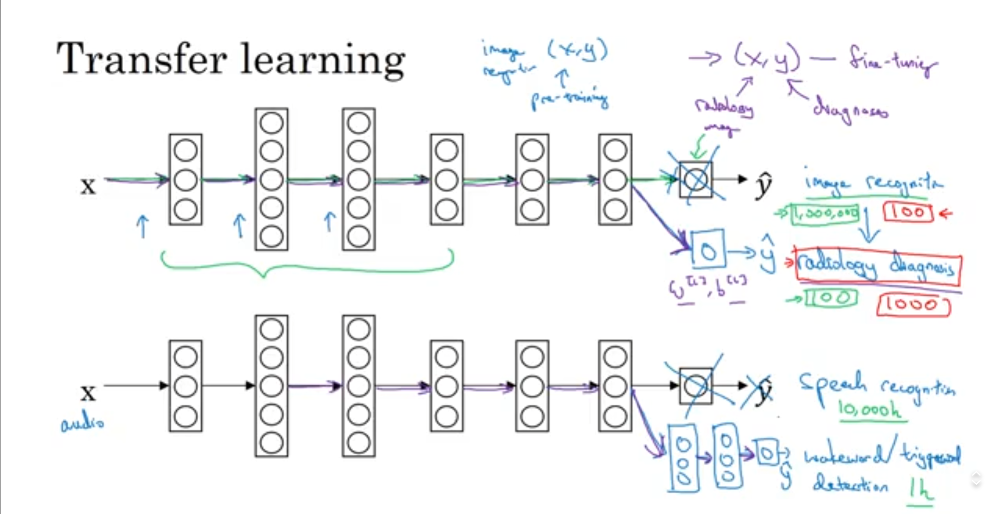

### 2. Hai chế độ vận hành chính: Feature Extraction và Fine-Tuning

Một mô hình CNN chuẩn thường chia làm hai phần: **Backbone** (Phần thân trích xuất đặc trưng - gồm các lớp Convolutional) và **Head** (Phần đầu phân loại - gồm các lớp Linear/Fully Connected). Dựa vào đây, ta có 2 chế độ:

- **Feature Extraction (Trích xuất đặc trưng):**
  - **Cơ chế:** Đóng băng (Freeze) toàn bộ các lớp thuộc Backbone (gán `requires_grad = False`). Gắn một Head mới hoàn toàn vào cuối mạng. Quá trình huấn luyện chỉ cập nhật trọng số cho phần Head này.
  - **Ưu điểm:** Cực kỳ nhanh và tiết kiệm tài nguyên. Do Backbone bị đóng băng, đầu ra của nó cho một bức ảnh là bất biến. Các nhà nghiên cứu thường tối ưu bằng cách cho toàn bộ dữ liệu chạy qua Backbone một lần, **lưu các vector đặc trưng xuống ổ cứng (Save to disk)**, sau đó chỉ dùng các vector này để huấn luyện phần Head như một mạng nơ-ron nông thông thường.
- **Fine-Tuning (Tinh chỉnh):**
  - **Cơ chế:** Rã đông (Unfreeze) một phần hoặc toàn bộ Backbone. Quá trình huấn luyện sẽ cập nhật trọng số của cả Head mới và các lớp được rã đông của mạng cũ.
  - **Ưu điểm:** Khai thác tối đa sức mạnh mô hình, ép các bộ lọc (filters) nhận diện đặc trưng thay đổi hình thái để phù hợp tuyệt đối với dữ liệu mới.

### 3. Quy tắc chọn chế độ (Dựa trên quy mô dữ liệu và Khoảng cách với ImageNet)

Chiến lược Transfer Learning không cố định mà phụ thuộc vào bản chất tập dữ liệu đích. Ta có 4 góc phần tư chiến lược:

1. **Dữ liệu NHỎ + Rất GIỐNG ImageNet (VD: Phân loại giống chó):**
   - **Chiến lược:** *Feature Extraction* ở lớp cuối cùng.
   - **Lý do:** Tránh Overfitting do dữ liệu nhỏ. Vì ảnh tương đồng, các đặc trưng cấp cao (mắt, mũi chó) mà mô hình gốc trích xuất đã quá đủ để phân loại.

2. **Dữ liệu LỚN + Rất GIỐNG ImageNet:**
   - **Chiến lược:** *Fine-Tuning toàn bộ* mạng.
   - **Lý do:** Dữ liệu dồi dào triệt tiêu rủi ro Overfitting. Việc tinh chỉnh toàn cục giúp đẩy độ chính xác (Accuracy) lên mức tối đa.

3. **Dữ liệu LỚN + KHÁC BIỆT ImageNet (VD: Ảnh y tế lớn):**
   - **Chiến lược:** *Fine-Tuning toàn bộ* mạng.
   - **Lý do:** Các đặc trưng của ImageNet không còn tác dụng. Ta dùng trọng số ImageNet chỉ để mô hình hội tụ nhanh hơn khởi tạo ngẫu nhiên, sau đó ép nó học lại toàn bộ bộ lọc mới nhờ lượng dữ liệu lớn.

4. **Dữ liệu NHỎ + KHÁC BIỆT ImageNet (VD: Ảnh X-Quang, Ảnh vệ tinh - Tình huống khó nhất):**
   - **Chiến lược:** *Feature Extraction từ các lớp giữa* (Intermediate Feature Extraction).
   - **Lý do:** Tiến thoái lưỡng nan: không thể Fine-tune vì sẽ Overfitting, không thể Feature Extraction ở cuối vì đặc trưng ImageNet (mắt mèo, bánh xe) trở nên vô dụng với ảnh X-Quang. Giải pháp là **cắt bỏ các lớp cuối**, giữ lại các lớp đầu/giữa (nơi trích xuất các đặc trưng vật lý phổ quát như đường thẳng, góc chéo, mảng sáng tối). Sau đó đóng băng phần này và gắn Head mới vào điểm cắt để tự học cách kết hợp các "cạnh/họa tiết" thành dấu hiệu bệnh lý.

### 4. Tối ưu hóa cập nhật trọng số: Discriminative Learning Rates

Khi bắt buộc phải rã đông (Fine-Tuning) toàn bộ mạng, việc dùng một Learning Rate (LR) duy nhất sẽ gây ra thảm họa **Catastrophic Forgetting** (sóng sai số lớn từ Head mới phá nát các đặc trưng hoàn hảo ở Backbone). Khái niệm *Discriminative Learning Rates (Tốc độ học phân tán)* do nhóm fast.ai đề xuất giải quyết triệt để vấn đề này.

**Nguyên lý:** Phân bổ LR theo mức độ "trưởng thành" của từng nhóm lớp:

- **Early layers (Các lớp đầu):** Nơi học các đặc trưng phổ quát (cạnh, nếp gấp, gradient màu). Trọng số ở đây gần như hoàn hảo cho mọi bài toán. Gán LR cực nhỏ (VD: $1e^{-5}$) để chỉ nắn chỉnh vi mô.
- **Middle layers (Các lớp giữa):** Nơi học các cấu trúc phức tạp hơn (hình khối, họa tiết). Gán LR vừa phải (VD: $1e^{-4}$) để mô hình điều chỉnh hình khối cho sát miền dữ liệu mới.
- **Custom Head (Phần đầu mới):** Vừa được khởi tạo với trọng số ngẫu nhiên, hoàn toàn "mù tịt" về bài toán. Gán LR lớn nhất (VD: $1e^{-3}$) để thúc đẩy hội tụ nhanh chóng.

### 5. Thiết kế khối phân loại (Head Design) hiện đại

Thay vì chỉ gắn một lớp `Linear` mỏng manh ở cuối mạng (dễ dẫn đến Underfitting hoặc hao hụt thông tin), các kiến trúc sư AI hiện đại thiết kế Custom Head như một hệ thống mạng nơ-ron phân tích chuyên sâu gồm 5 bước nối tiếp:

1. **Adaptive Pooling (Gom cụm toàn cục thích ứng):** Khác với Pooling trong Backbone (nhằm giảm chiều không gian), Pooling ở Head ép khối Tensor 3D (Channels x H x W) về một điểm duy nhất (1x1). Các Head chất lượng cao thường tính cả **Max** (bắt giữ đặc trưng nổi bật nhất, kỳ dị nhất) và **Avg** (bắt giữ tổng thể bối cảnh không gian), sau đó ghép (Concat) chúng lại để không bỏ sót manh mối nào.
2. **Flatten (Duỗi tensor):** Chuyển đổi ma trận không gian về dạng Vector 1D để tương thích với mạng nơ-ron cổ điển.
3. **BatchNorm1d & Dropout:** Lớp khiên bảo vệ. BatchNorm giúp chuẩn hóa phân phối dữ liệu, ổn định quá trình lan truyền ngược. Dropout tắt ngẫu nhiên nơ-ron, ép mô hình phân tán học tập, là vũ khí tối thượng chống Overfitting trên Dataset nhỏ.
4. **Linear (Ẩn) + ReLU:** Lớp mạng ẩn trung gian đóng vai trò kết hợp các đặc trưng rời rạc thành các cấu trúc logic phức tạp có tính phi tuyến (nhờ hàm kích hoạt ReLU).
5. **Linear (Output):** Lớp thu nhỏ cuối cùng (số nơ-ron bằng đúng số lượng Classes) trả về các giá trị logits để xuất ra xác suất dự đoán (qua Softmax/CrossEntropy).

**Kết luận:** Sự kết hợp giữa một *Head Design* đa lớp, mạnh mẽ cùng quy tắc rã đông lũy tiến với *Discriminative Learning Rates* chính là nền tảng cốt lõi giúp các mô hình CV hiện đại dễ dàng phá vỡ các kỷ lục State-of-the-Art, ngay cả trong điều kiện tài nguyên dữ liệu hạn hẹp.

## II. Chỉ số đánh giá

### 1. IOU (Intersection over Union) – Thước Đo Độ Khớp Không Gian

**Mục đích sinh ra:** Để trả lời cho câu hỏi: *"Chiếc hộp cỗ máy vẽ ra khớp với Đáp án chuẩn do con người vẽ đến mức nào?"*

- **Định nghĩa:** IOU là tỷ lệ diện tích chồng lấp (Intersection) chia cho tổng diện tích hợp nhất (Union) giữa 2 chiếc hộp: Khung dự đoán (Predicted Box - Hộp A) và Khung chuẩn (Ground Truth Box - Hộp B).

- **Công thức tổng quát:**

  $$IOU = \frac{Diện\ tích\ Giao\ nhau\ (Overlap)}{Diện\ tích\ Hợp\ nhất\ (Union)}$$

- **Khai triển toán học chi tiết:** Giả sử Hộp A được xác định bởi tọa độ góc trên-trái $(x1_A,y1_A)$ và góc dưới-phải $(x2_A,y2_A)$; Hộp B được xác định bởi tọa độ góc trên-trái $(x1_B,y1_B)$ và góc dưới-phải $(x2_B,y2_B)$.

  - **Diện tích độc lập:**

    $$Area_A = (x2_A-x1_A)\times(y2_A-y1_A)$$

    $$Area_B = (x2_B-x1_B)\times(y2_B-y1_B)$$

  - **Diện tích Giao nhau (Intersection):** Hệ thống tìm tọa độ vùng chồng lấp bằng cách bóp nghẹt giới hạn từ hai phía (chọn biên sâu nhất từ ngoài vào và biên hẹp nhất từ trong ra). Nếu hai hộp không đè lên nhau, hàm max(0,…) sẽ ép chiều dài/rộng về 0.

    $$WI = max(0,min(x2_A,x2_B)-max(x1_A,x1_B))$$

    $$HI = max(0,min(y2_A,y2_B)-max(y1_A,y1_B))$$

    $$Intersection = WI\times HI$$

  - **Diện tích Hợp nhất (Union):** Áp dụng nguyên lý bù trừ tập hợp để loại bỏ phần diện tích bị tính lặp lại hai lần.

    $$Union = Area_A+Area_B-Intersection$$

  - **Phương trình hoàn chỉnh:**

    $$IOU = \frac{WI\times HI}{Area_A+Area_B-(WI\times HI)}$$

- **Khoảng giá trị:** Từ 0 (Hai hộp rời rạc hoàn toàn) đến 1 (Hai hộp đè lên nhau khít 100%).

- **Vai trò thực tiễn (IOU dùng để làm gì?):**
  1. **Huấn luyện (Training):** Dùng làm trọng tài để quyết định xem chiếc hộp nào trong ô lưới có quyền trở thành "Hộp chịu trách nhiệm" (Target Assignment).
  2. **Sàng lọc NMS (Inference):** Dùng để triệt tiêu các hộp trùng lặp đè lên cùng một vật thể ở khâu hậu xử lý.
  3. **Chấm điểm đúng/sai (Evaluation):** Thiết lập một "Ngưỡng chấp nhận" (Threshold). Ví dụ: Kỹ sư quy định IOU>0.5 mới được tính là đoán trúng vị trí (True Positive), dưới 0.5 bị coi là đoán trượt (False Positive) dù có gọi đúng tên vật thể đi chăng nữa.



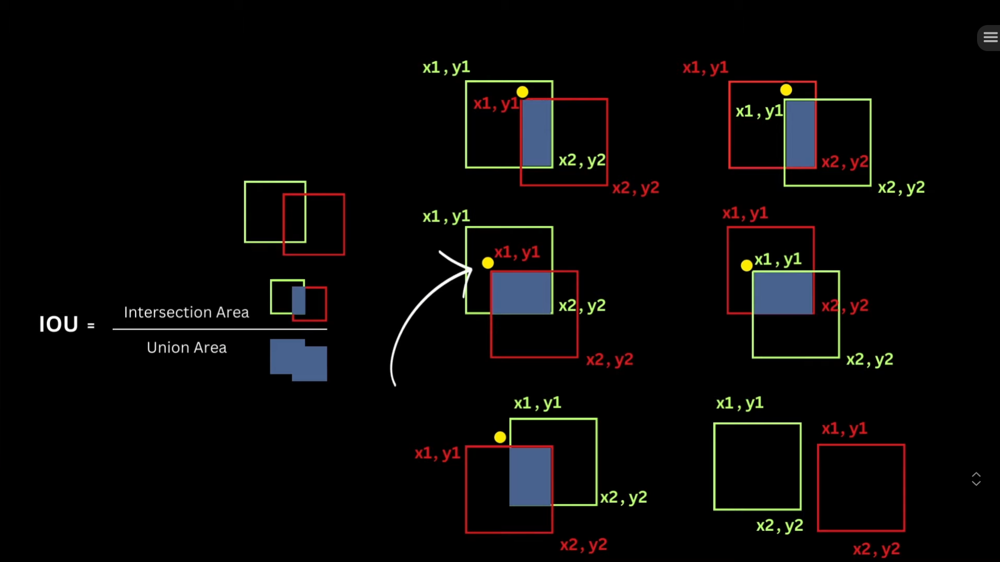

### 2. Tiền đề Bắt buộc: Cấu Trúc Phân Loại Nhị Phân (TP, FP, FN) & Precision/Recall

Sau khi tính toán được IOU, hệ thống đánh giá không sử dụng IOU trực tiếp làm điểm số mà dùng nó như một "màng lọc" để phân loại hàng ngàn chiếc hộp do máy dự đoán thành 3 nhóm trạng thái. Đặc thù của bài toán Nhận diện vật thể (Object Detection) là không sử dụng True Negative (TN), vì số lượng ô nền trống (background) trong một bức ảnh là vô hạn.

### A. Giải phẫu 3 trạng thái dự đoán:

**True Positive (TP - Báo động đúng):** Một dự đoán được tính là TP khi thỏa mãn ĐỒNG THỜI 2 điều kiện:

- Đoán đúng danh mục (Class) của vật thể.
- Độ khớp không gian đạt chuẩn: $IOU \ge Threshold$ (Thường cài đặt ở mức $0.5$).

**False Positive (FP - Báo động giả):** Đây là "điểm trừ" của cỗ máy, xảy ra trong 3 trường hợp:

- Đoán sai danh mục (Thấy con mèo đoán thành con chó).
- Khoanh trượt vật thể: Đoán đúng danh mục nhưng $IOU < Threshold$.
- Lỗi trùng lặp (Duplicate): Bức ảnh chỉ có 1 chiếc xe, nhưng máy vẽ ra 2 chiếc hộp đè lên chiếc xe đó. Hộp có điểm tự tin cao nhất tính là TP, hộp còn lại lập tức bị đánh tụt thành FP.

**False Negative (FN - Bỏ lọt):** Đây là lỗi "mù" của cỗ máy. Xảy ra khi có một Đáp án chuẩn (Ground Truth) nhưng hệ thống không sinh ra bất kỳ chiếc hộp nào khớp với nó ($IOU \ge 0.5$).

### B. Định lượng Hợp nhất: Precision và Recall

Từ 3 mảnh ghép trên, hệ thống đúc kết ra hai chỉ số định lượng năng lực cốt lõi:

**Precision (Độ chính xác - Sự cẩn trọng):**

$$
Precision = \frac{TP}{TP + FP}
$$

Chỉ số này đo lường "độ tín nhiệm". Trị số này càng cao (tiến gần về 1), chứng tỏ một khi cỗ máy đã quyết định vẽ hộp thì tỷ lệ đúng rất cao, ít sinh ra rác hoặc báo động giả.

**Recall (Độ bao quát - Sự nhạy bén):**

$$
Recall = \frac{TP}{TP + FN}
$$

Chỉ số này đo lường "khả năng quét sạch". Trị số này càng cao chứng tỏ cỗ máy hiếm khi bỏ sót vật thể trong khung hình.

**Nghịch lý đánh đổi (The Trade-off):** Precision và Recall luôn có xu hướng triệt tiêu lẫn nhau. Nếu bạn hạ Ngưỡng tự tin (Confidence Threshold) xuống thấp để cỗ máy vẽ ra thật nhiều hộp, Recall sẽ tăng (không lọt vật nào), nhưng FP cũng tăng vọt khiến Precision cắm đầu đi xuống.


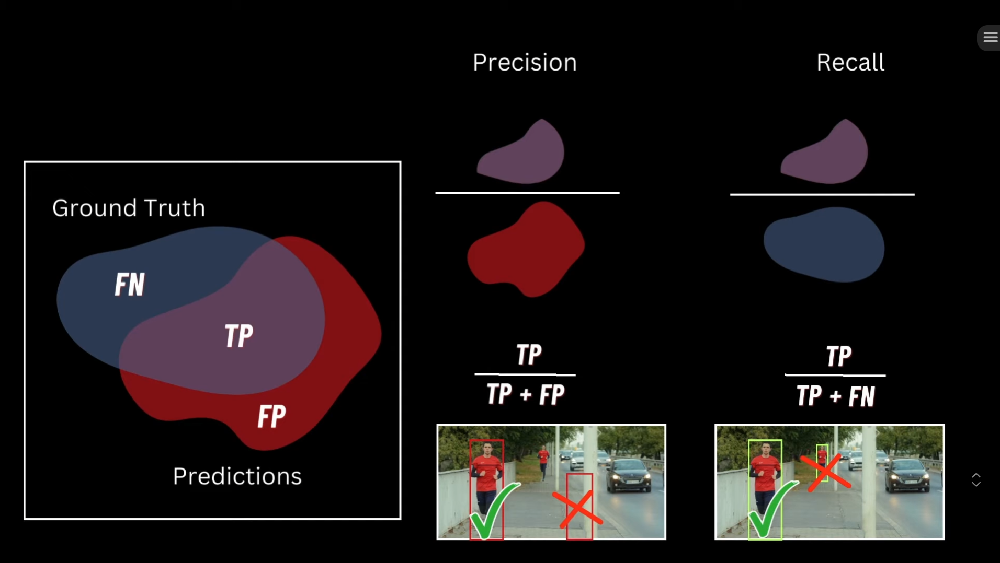


### 3. AP (Average Precision) – Chấm Điểm Toàn Diện Cho Từng Danh Mục

Do sự mâu thuẫn nội tại giữa Precision và Recall, ta không thể so sánh hai mô hình nếu chỉ nhìn vào một điểm cắt (Threshold) duy nhất. AP sinh ra để tóm gọn toàn bộ sự biến thiên của Precision và Recall trên một danh mục vật thể (ví dụ: "Chó") thành một con số duy nhất.

**Bản chất toán học:** AP chính là diện tích vùng nằm dưới Đường cong Precision-Recall (Area Under the PR Curve).

**Công thức gốc (Tích phân):**

$$
AP = \int_{0}^{1} P(R) \,dR
$$

**Thuật toán Rời rạc hóa (Interpolated AP):** Máy tính không thể tính tích phân liên tục, nên hệ thống sử dụng phép nội suy. Theo tiêu chuẩn PASCAL VOC, trục Recall (từ 0 đến 1) được chia thành 11 mốc cố định: $0.0, 0.1, \dots, 1.0$. Tại mỗi mốc $r$, hệ thống không lấy giá trị Precision hiện tại, mà quét về phía bên phải đồ thị để lấy giá trị Precision lớn nhất ($P_{interp}$).

$$
P_{interp}(r) = \max_{\tilde{r} \ge r} P(\tilde{r})
$$

Sau đó, hệ thống tính trung bình cộng của 11 điểm nội suy này:

$$
AP = \frac{1}{11} \sum_{r \in \{0.0, \dots, 1.0\}} P_{interp}(r)
$$

**Lợi ích:** Kỹ thuật lấy $\max$ này giúp triệt tiêu các điểm gãy gập thất thường của đường cong, tạo ra một đồ thị đơn điệu giảm, phản ánh đúng năng lực bền vững của mô hình.


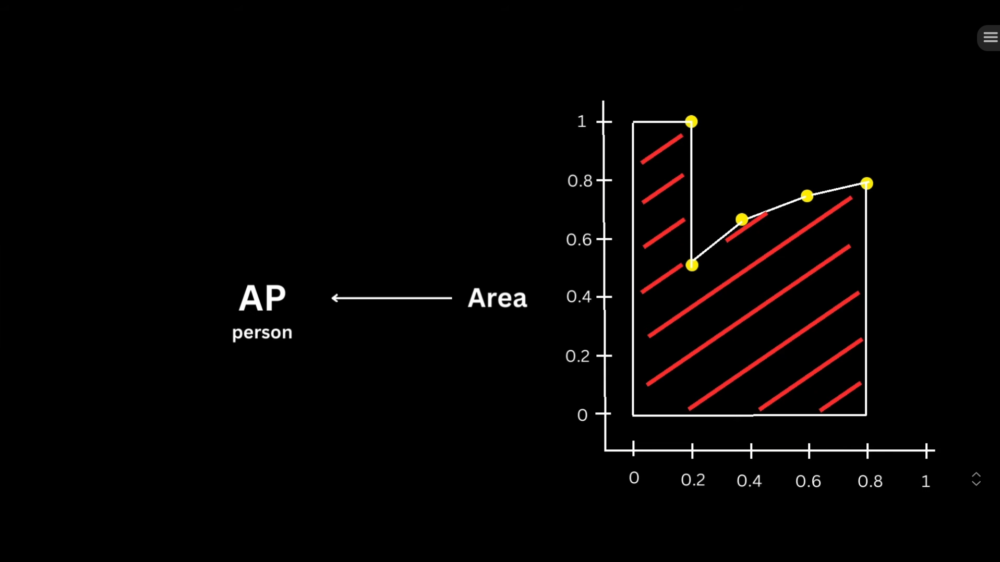


### 4. mAP (Mean Average Precision) – Tiêu Chuẩn Vàng Của Kiến Trúc Mạng

AP chỉ đánh giá cỗ máy trên từng loại vật thể độc lập. Để có một thước đo tối thượng, xếp hạng sức mạnh tổng thể của toàn bộ kiến trúc (ví dụ YOLOv1 so với Faster R-CNN), giới nghiên cứu sử dụng mAP.

**Bản chất:** Là trung bình cộng của tất cả các giá trị AP từ mọi danh mục (Class) mà tập dữ liệu yêu cầu.

**Công thức cơ sở (Tiêu chuẩn PASCAL VOC - mAP@0.5):**

$$
mAP = \frac{1}{N} \sum_{i=1}^{N} AP_i
$$

Trong đó $N$ là tổng số danh mục (PASCAL VOC có $N=20$). Chỉ số này được tính cố định tại ngưỡng $IOU = 0.5$.

**Sự tiến hóa khắt khe (Tiêu chuẩn COCO - mAP@[.5:.95]):**

Các thuật toán ngày càng mạnh, ngưỡng $IOU = 0.5$ trở nên quá dễ dãi. Bộ dữ liệu COCO ép cỗ máy vào một hệ thống chấm điểm tàn khốc hơn nhiều:

- Tính mAP tại ngưỡng $IOU = 0.50$.
- Tăng dần ngưỡng $IOU$ lên một nấc $0.05$ (tức là $0.55, 0.60, 0.65, \dots$) và tính lại mAP.
- Lặp lại cho đến ngưỡng $IOU = 0.95$ (đòi hỏi hộp phải ôm khít vật thể đến từng pixel).
- Tính trung bình cộng của toàn bộ 10 mốc mAP này.

Chỉ số mAP@[.5:.95] vắt kiệt năng lực của mô hình, buộc mạng nơ-ron không chỉ phải nhận diện xuất sắc (đạt Classification tốt) mà còn phải tinh chỉnh tọa độ hình học (Localization) một cách hoàn hảo tuyệt đối.

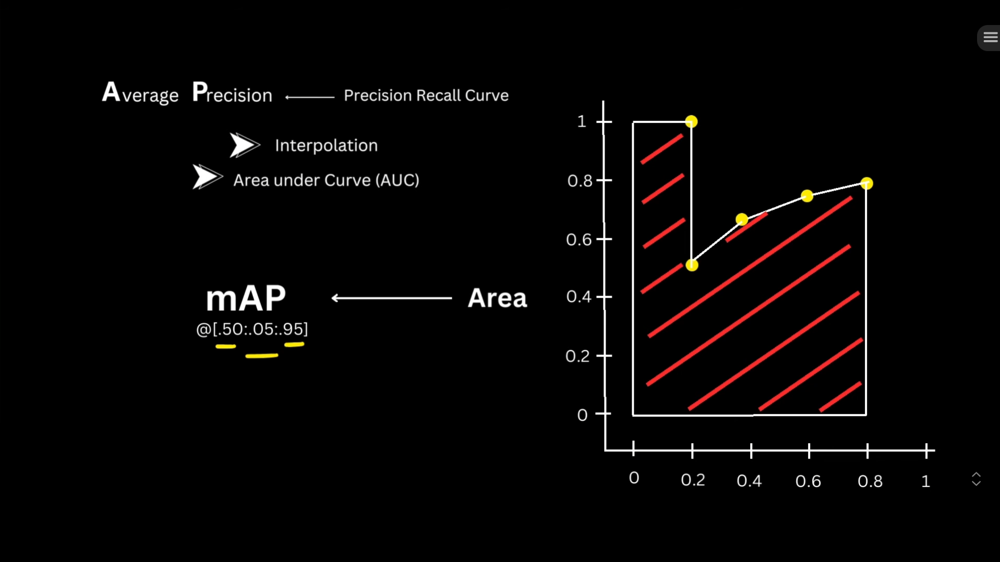



# II. Object Detection
## 1. RCNN
### 1.1. Giai đoạn training 
#### a. Khởi tạo và Gán nhãn Hộp ứng viên (Giai đoạn CNN)

Quá trình định hình dữ liệu đầu vào bắt đầu bằng việc không sử dụng cửa sổ trượt mù quáng mà nhờ cậy vào một thuật toán trinh sát độc lập.

- **Chọn hộp ứng viên:** Thuật toán Selective Search quét bức ảnh gốc, gom cụm các pixel có sự tương đồng về màu sắc và kết cấu để sinh ra khoảng 2.000 Hộp ứng viên (Region Proposals) với đủ mọi kích thước và tỷ lệ.
- **Tiền xử lý (Warping):** Vì mạng CNN yêu cầu kích thước đầu vào cố định, toàn bộ 2.000 chiếc hộp này bị bóp méo hoặc kéo giãn ép về đúng độ phân giải $227 \times 227$ pixel.
- **Chiến lược Gán nhãn (Dễ dãi):** Hệ thống đo mức độ chồng lấp (IoU) của từng hộp ứng viên với Đáp án chuẩn (Ground Truth - GT). Các hộp đạt $IoU \ge 0.5$ được gắn nhãn Dương (thuộc một lớp vật thể). Các hộp có $IoU < 0.5$ mang nhãn Âm (Nền trống). Ngưỡng 0.5 nới lỏng này giúp nhân bản số lượng mẫu lên hàng chục lần, cung cấp một lượng dữ liệu đồ sộ để mạng CNN không bị Overfitting.


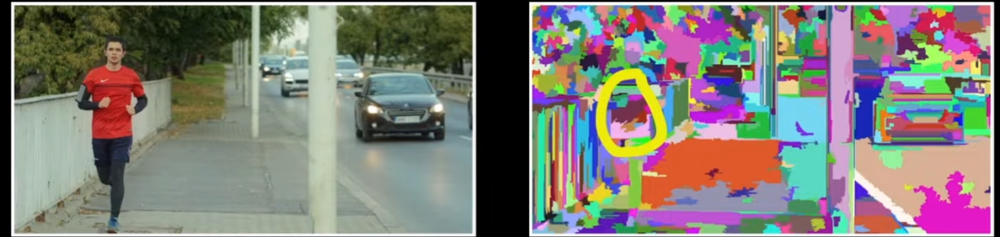

#### b. Trích xuất Đặc trưng qua Mạng CNN

2.000 chiếc hộp ứng viên mang nhãn bắt đầu hành trình đi qua mạng nơ-ron chập (thường là kiến trúc AlexNet).

- **Lan truyền xuôi:** Dữ liệu trượt qua 5 lớp Tích chập (Convolutional Layers) để chắt lọc từ các đường nét cơ bản đến những hình khối phức tạp. Sau khi đi qua các lớp Max Pooling, khối dữ liệu 3D bị "là phẳng" và chảy vào lớp Kết nối đầy đủ (Fully Connected - FC).
- **Đầu ra Vector:** Tại lớp FC7, toàn bộ đặc trưng thị giác của một chiếc hộp được cô đặc lại thành một Vector đặc trưng tĩnh 4096 chiều.
- **Học và Đóng băng:** Mạng sử dụng Cross-Entropy Loss để tính toán sai số và dùng Backpropagation cập nhật trọng số. Khi Loss đạt mức tối ưu, mạng CNN bị "đóng băng". Hàng triệu Vector 4096 chiều từ các bức ảnh được trích xuất và lưu thẳng ra ổ cứng để làm nguyên liệu cho chặng sau.

> **Bổ sung Công thức và Giải thích Hàm Loss cho Chặng 1 (Mạng CNN):**
>
> - **Công thức (Cross-Entropy Loss):**
>
>   $$
>   L_{cls} = -\sum_{i=1}^{C} y_i \log(p_i)
>   $$
>
> - **Giải thích:** Trong đó $C$ là tổng số lớp phân loại (bao gồm cả lớp nền), $y_i$ là nhãn thực tế (nhận giá trị 1 nếu đúng lớp, 0 nếu sai), và $p_i$ là xác suất dự đoán do mạng nơ-ron xuất ra. Hàm Loss này trừng phạt nặng nề khi mô hình dự đoán xác suất sai lệch lớn so với nhãn thực tế, buộc thuật toán tối ưu hóa điều chỉnh lại bộ trọng số qua các bước lan truyền ngược.


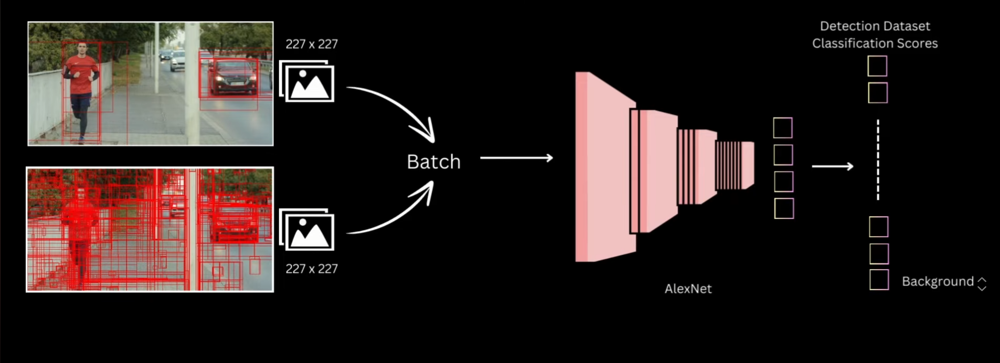


#### c. Tái Gán nhãn và Xử lý tại Cụm SVM

Khi chuyển sang huấn luyện Cụm SVM, hệ thống bắt buộc phải gán lại một hệ thống nhãn mới hoàn toàn độc lập và khắc nghiệt hơn rất nhiều so với giai đoạn CNN.

- **Luật Gán nhãn mới (Khắt khe):** SVM chỉ chấp nhận dữ liệu tinh khiết. Chỉ chiếc hộp Đáp án chuẩn nguyên bản ($IoU = 1.0$) mới được giữ lại làm nhãn Dương. Những hộp có $IoU < 0.3$ nhận nhãn Âm. Toàn bộ "Vùng xám" ($0.3 \le IoU < 1.0$) bị vứt bỏ hoàn toàn để vạch ra Vùng đệm (Margin) an toàn cho thuật toán toán học.
- **Xử lý và Chấm điểm:** Cụm SVM (mỗi lớp vật thể có một SVM riêng) đọc các Vector 4096 chiều tĩnh từ ổ cứng. Nó thực hiện phép nhân vô hướng giữa ma trận trọng số $W_{svm}$ và Vector để xuất ra Điểm tự tin (Confidence Score).
- **Tinh chỉnh bằng Hard Negative Mining:** Để giải quyết tình trạng thiếu hụt mẫu Dương, SVM liên tục chấm điểm các mẫu Âm và chủ động nhặt ra những mẫu "bị nhận nhầm với điểm cao" (ví dụ: chiếc lốp xe bị nhầm là ô tô) để đưa vào học lại, ép ranh giới phân loại trở nên sắc bén.

> **Bổ sung Công thức và Giải thích Hàm Loss cho Chặng 2 (Cụm SVM):**
>
> - **Công thức (Hinge Loss):**
>
>   $$
>   L_{svm} = \sum_{i=1}^{N} \max(0, 1 - y_i (W^T \phi(P_i) + b))
>   $$
>
> - **Giải thích:** Trong đó $y_i \in \{-1, 1\}$ là nhãn phân loại, $\phi(P_i)$ là Vector đặc trưng 4096 chiều, $W$ và $b$ là trọng số cùng độ lệch của mặt phẳng phân cách SVM. Hàm Loss này đảm bảo các mẫu đúng nằm cách xa ranh giới một khoảng an toàn (Margin $\ge 1$). Nếu mẫu dự đoán nằm sai phía hoặc chưa đạt đủ biên độ an toàn, hệ thống sẽ sinh ra điểm phạt tuyến tính để ép SVM dịch chuyển mặt phẳng phân cách.


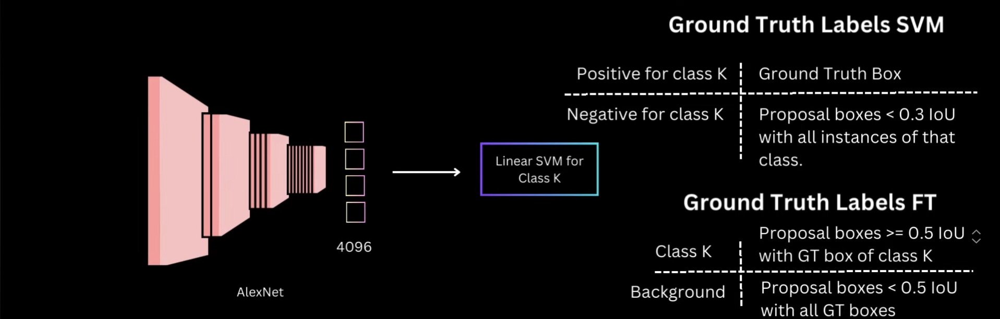


#### d. Thuật toán Hồi quy Tuyến tính (Nắn Tọa độ)

Bộ định chuẩn Bounding Box Regressor chạy song song với SVM, làm nhiệm vụ biến các chiếc hộp ứng viên lỏng lẻo ôm khít vào vật thể thực tế. Nó chỉ lấy những hộp đã bám sát mục tiêu ($IoU \ge 0.6$) để huấn luyện.

- **Mục tiêu Toán học:** Máy tính không học số pixel tuyệt đối vì chúng phụ thuộc vào độ to nhỏ của vật thể. Hệ thống chuyển đổi tọa độ hộp dự đoán ($P$) và hộp thực tế ($G$) thành 4 hệ số biến thiên:
  - **Hệ số Dịch tâm:** $t_x = \frac{G_x - P_x}{P_w}$ và $t_y = \frac{G_y - P_y}{P_h}$ (Chia cho kích thước hiện tại để mô hình học theo tỷ lệ phần trăm).
  - **Hệ số Co giãn:** $t_w = \log\left(\frac{G_w}{P_w}\right)$ và $t_h = \log\left(\frac{G_h}{P_h}\right)$ (Dùng logarit để đảm bảo tính đối xứng trên trục số và ngăn việc dự đoán ra chiều dài âm).
- **Huấn luyện và Suy luận:** Mô hình Ridge Regression (L2 Loss) tối ưu hóa một ma trận trọng số $W_{reg}$. Khi thực chiến, Vector 4096 chiều nhân với ma trận này sẽ sinh ra 4 hệ số dự đoán. Ngay lập tức, máy tính dùng hàm $\exp$ và phép nhân để đảo ngược toán học, nắn chiếc hộp về hệ tọa độ pixel chuẩn trên màn hình.

> **Bổ sung Công thức và Giải thích Hàm Loss cho Chặng 3 (Regressor):**
>
> - **Công thức (Ridge Regression / L2 Loss):**
>
>   $$
>   L_{reg} = \sum_{i=1}^{N} (t_*^i - W_*^T \phi(P_i))^2 + \lambda ||W_*||^2
>   $$
>
> - **Giải thích:** Trong đó $t_*^i$ là các hệ số dịch chuyển thực tế cần đạt được, $W_*^T \phi(P_i)$ là giá trị dự đoán từ mô hình hồi quy tuyến tính, và $\lambda ||W_*||^2$ là số hạng điều chuẩn L2 Penalty. Hàm Loss này tính tổng bình phương sai số giữa dự đoán và thực tế, kết hợp việc kìm hãm trọng số $W$ không bị phình to nhằm ngăn chặn hiện tượng quá khớp (Overfitting) trên dữ liệu huấn luyện.


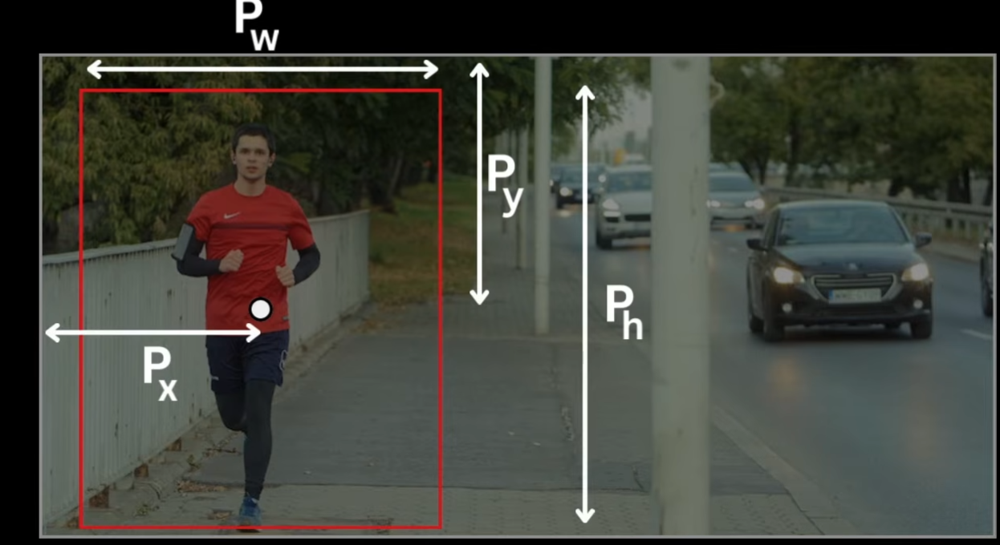


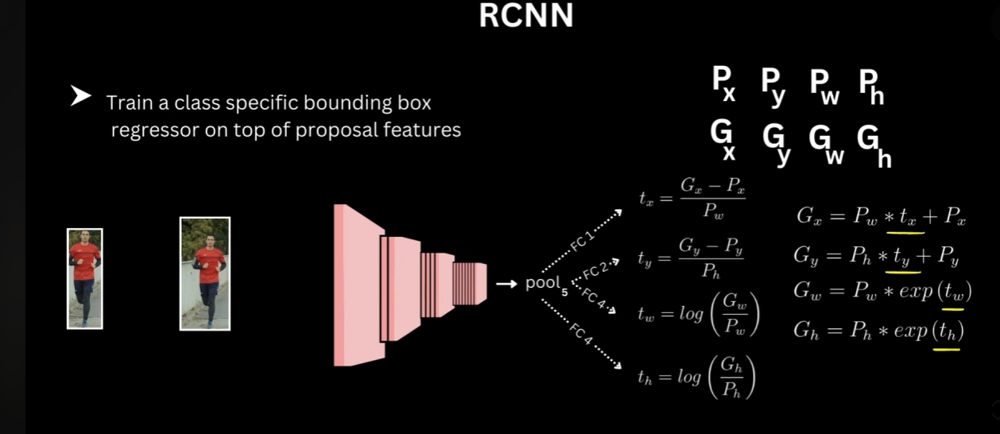

### 1.2. Giai đoạn chạy thực tế

#### a. Cắt mẻ lưới ứng viên đầu tiên (Selective Search & Warping)

Mạng CNN (AlexNet) lúc này không còn học hỏi nữa mà đóng vai trò như một màng lọc quang học tĩnh (với bộ trọng số đã bị khóa cứng).

- Thuật toán Selective Search quét bức ảnh mới để tạo ra khoảng 2.000 Hộp ứng viên, sau đó thực hiện tiền xử lý Warp toàn bộ các hộp về kích thước cố định $227 \times 227$ pixel.

#### b.  Đun chảy hình ảnh thành Toán học

- **Lan truyền xuôi tốc độ cao:** 2.000 bức ảnh con lần lượt chạy qua các lớp Tích chập (Convolution) để làm nổi bật các cạnh, góc và hình khối.
- **Cô đặc dữ liệu:** Khi đến lớp Kết nối đầy đủ (FC7) cuối cùng, ma trận hình ảnh 3D bị "là phẳng" và hóa thân thành 2.000 Vector đặc trưng tĩnh. Mỗi vector là một chuỗi số dài 4096 chiều, chứa đựng toàn bộ nhận thức cốt lõi của AI về khung hình đó.

#### c.  Chấm điểm và Nắn tọa độ song song

2.000 Vector đặc trưng lập tức được phân luồng đi qua hai cụm thuật toán chạy song song với nhau:

- **A. Chấm điểm tại Cụm SVM (Phân loại):**
  - Mỗi Vector 4096 chiều được nhân vô hướng với ma trận trọng số của từng lớp vật thể (như SVM của Ô tô, SVM của Người).
  - Phép tính toán học này trả về một Điểm tự tin (Confidence Score) cho từng chiếc hộp, giúp hệ thống có thể phân tách các trường hợp dự đoán theo từng lớp riêng biệt.
- **B. Hóa phép Đảo ngược tại Bounding Box Regressor (Nắn khung):**
  - Cùng lúc đó, Vector đi qua ma trận trọng số của bộ hồi quy để xuất ra 4 hệ số tỷ lệ $(t_x, t_y, t_w, t_h)$.
  - Máy tính ngay lập tức dùng Toán học đảo ngược để dịch các hệ số tương đối này về tọa độ pixel tuyệt đối trên bức ảnh gốc:
    - Dịch ngược tâm tọa độ: $\hat{G}_x = P_w \cdot t_x + P_x$ và $\hat{G}_y = P_h \cdot t_y + P_y$.
    - Dịch ngược kích thước (dùng hàm $\exp$ để phá vỡ Logarit): $\hat{G}_w = P_w \cdot \exp(t_w)$ và $\hat{G}_h = P_h \cdot \exp(t_h)$.
  - Kết quả của Trạm 3 là 2.000 khung hình đã được nắn lại thẳng thớm, kèm theo nhãn và điểm số tự tin cho từng khung.

#### d.  Thuật toán NMS (Non-Maximum Suppression)

Bức ảnh lúc này là một mớ hỗn độn vì một vật thể có thể bị hàng chục chiếc hộp cùng khoanh trúng. Thuật toán NMS được kích hoạt để dọn dẹp theo từng danh mục:

- **Xếp hạng:** Hệ thống lấy các hộp dự đoán cùng một nhãn, sắp xếp chúng theo Điểm tự tin từ cao xuống thấp (ví dụ: hộp $0.92$ đứng trước hộp $0.89$ và $0.75$).
- **Chọn Vua:** Chiếc hộp có điểm cao nhất được phong làm "Vua" và chắc chắn được in ra màn hình.
- **Đo đạc IoU và Xóa sổ:** Hệ thống lấy hộp Vua đo diện tích chồng lấp (IoU) với tất cả các hộp cấp thấp hơn ở bên dưới. Để đo vùng giao nhau chính xác, thuật toán sử dụng hàm lớn nhất $\max$ cho tọa độ $y_1$ (do trục Y của ảnh đâm ngược từ trên xuống).
- **Triệt tiêu:** Bất kỳ chiếc hộp cấp thấp nào đè lên Vua với tỷ lệ IoU vượt quá ngưỡng cho phép (ví dụ $> 0.3$) sẽ bị xóa sổ hoàn toàn khỏi hệ thống.

  Quá trình quét và dọn dẹp này lặp lại cho đến khi không còn chiếc hộp nào bị trùng lặp. Hệ thống xuất ra bức ảnh cuối cùng với những khung Bounding Box sắc nét, chính xác và duy nhất cho mỗi vật thể, khép lại toàn bộ vòng đời suy luận của R-CNN.

## 2. Fast R-CNN
Fast R-CNN không chỉ là một bản vá lỗi về tốc độ, mà là một cuộc tái cấu trúc tư duy định hình lại toàn bộ cách máy tính trích xuất và học hỏi đặc trưng hình ảnh. Để vươn tới kiến trúc End-to-End (huấn luyện từ đầu đến cuối), Fast R-CNN đã dũng cảm đập bỏ công xưởng chắp vá của thế hệ R-CNN tiền nhiệm.

### 2.1. Giai đoạn training (Huấn luyện)

#### a. Khởi tạo và Trích xuất Đặc trưng Toàn cục (Shared CNN)

Khác với R-CNN phải băm nát bức ảnh, Fast R-CNN tối ưu hóa triệt để bằng cách xử lý bức ảnh nguyên bản.

- **Lan truyền xuôi một lần:** Bức ảnh gốc (không bị cắt xén) được đẩy qua mạng nơ-ron chập (CNN) đúng một lần duy nhất. Các lớp Tích chập quét qua toàn bộ bức ảnh để trích xuất ra một Bản đồ đặc trưng (Feature Map) khổng lồ chứa đựng toàn bộ thông tin không gian và ngữ nghĩa của hình ảnh.
- **Đề xuất vùng độc lập:** Song song với quá trình trên, thuật toán Selective Search vẫn quét trên ảnh gốc để sinh ra khoảng 2.000 Hộp ứng viên (Region Proposals). Tuy nhiên, những hộp này giờ đây chỉ đóng vai trò là các bộ số tọa độ, chờ để được chiếu lên Bản đồ đặc trưng.

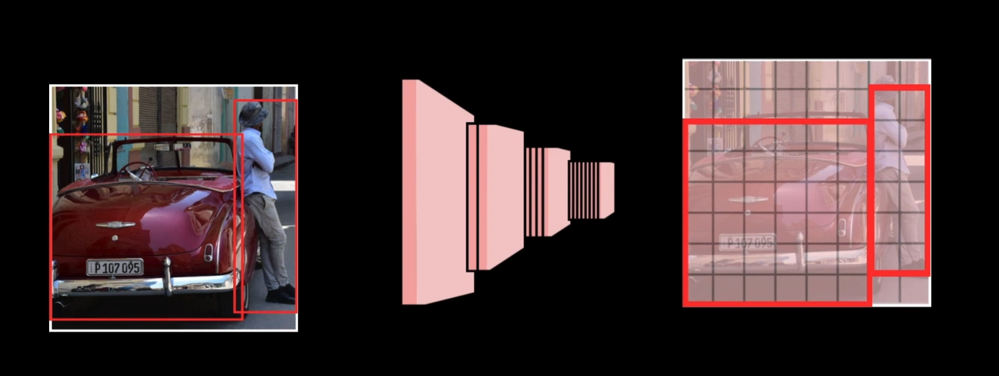


#### b. Lấy mẫu Phân cấp (Hierarchical Sampling)

Để giải quyết tình trạng cạn kiệt bộ nhớ và cân bằng dữ liệu, Fast R-CNN không nhồi nhét cả 2.000 hộp ứng viên vào mạng cùng lúc mà tạo ra các gói dữ liệu nhỏ (Mini-batch) với quy tắc khắt khe.

- **Gộp ảnh (N=2):** Thuật toán chọn ngẫu nhiên 2 bức ảnh gốc cho mỗi lượt cập nhật trọng số. Điều này giúp hệ thống chỉ phải tính toán 2 Bản đồ đặc trưng, tiết kiệm tài nguyên khổng lồ.
- **Chắt lọc 128 hộp (R=128):** Từ 2 bức ảnh, hệ thống bốc ra chính xác 128 hộp ứng viên (mỗi ảnh 64 hộp).
- **Chiến lược Gán nhãn Khắc nghiệt:**
  - **Mẫu Dương (25%):** Khoảng 32 hộp có tỷ lệ chồng lấp với Đáp án chuẩn $IoU \ge 0.5$ được gắn nhãn Vật thể.
  - **Mẫu Âm tính khó (75%):** Khoảng 96 hộp có $0.1 \le IoU < 0.5$ được gắn nhãn Nền trống. Việc ép mạng nơ-ron học trên những chiếc hộp khoanh lẹm vật thể này giúp triệt tiêu triệt để căn bệnh "báo động giả". Các hộp $IoU < 0.1$ bị vứt bỏ hoàn toàn trong lượt học đó.

#### c. Cắt và Ép khung qua lớp RoI Pooling

Đây là "trái tim" của Fast R-CNN, giải quyết bài toán hóc búa: Làm sao để các lớp Kết nối đầy đủ (FC) nhận được dữ liệu đầu vào kích thước cố định từ những chiếc hộp to nhỏ lộn xộn?

- **Chiếu tọa độ:** 128 chiếc hộp ứng viên được chiếu thẳng tọa độ từ ảnh gốc lên Bản đồ đặc trưng.
- **Chia lưới và Ép kiểu (Max Pooling):** Bất chấp hình thù của chiếc hộp trên Bản đồ đặc trưng là gì, RoI Pooling áp dụng một tấm lưới cố định (ví dụ $7 \times 7$). Trong mỗi ô của lưới, thuật toán lấy giá trị lớn nhất (Max Pooling). Kết quả, 128 vùng dữ liệu lộn xộn đều bị "ép" thành 128 khối ma trận có kích thước chuẩn hóa giống hệt nhau, sẵn sàng để dàn phẳng và đẩy vào các lớp FC.


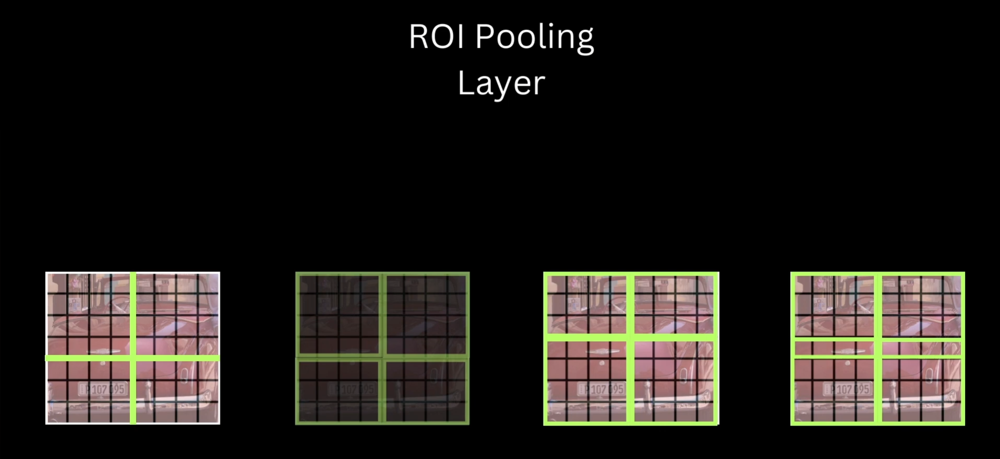

#### d. Phán quyết và Cập nhật trọng số (Multi-task Loss)

Fast R-CNN khai tử hoàn toàn các thuật toán ngoại vi như SVM hay Ridge Regression. Nó nhúng 2 nhánh Phân loại (Softmax) và Nắn tọa độ (Regressor) vào trực tiếp đuôi mạng CNN, tạo thành một hệ thống End-to-End.

- **Lan truyền xuôi qua FC:** 128 khối dữ liệu xuyên qua các lớp Fully Connected. Tại đầu ra, nhánh Softmax dự đoán xác suất cho $K+1$ lớp (gồm các vật thể và 1 lớp Nền), nhánh Regressor xuất ra 4 hệ số dịch chuyển tọa độ $(t_x, t_y, t_w, t_h)$.
- **Đánh giá bằng Hàm Mất mát kép:** Hệ thống gộp chung cả lỗi phân loại và lỗi tọa độ vào một hàm Multi-task Loss duy nhất.
- **Lan truyền ngược (Backpropagation):** Điểm phạt từ hàm Loss được tính đạo hàm và truyền ngược qua lớp RoI Pooling, về tận các lớp CNN đầu tiên. Toàn bộ trọng số của hệ thống được tinh chỉnh đồng bộ trong một nhịp đập.

> **Bổ sung Công thức và Giải thích Hàm Loss cho Fast R-CNN:**
>
> - **Công thức (Multi-task Loss):**
>
>   $$
>   L(p, u, t^u, v) = L_{cls}(p, u) + \lambda [u \ge 1] L_{loc}(t^u, v)
>   $$
>
> - **Giải thích:**
>   - $L_{cls}(p, u) = -\log(p_u)$ là hàm mất mát Cross-Entropy phạt sai sót trong việc phân loại của nhánh Softmax.
>   - $L_{loc}(t^u, v)$ sử dụng hàm Smooth L1 Loss để phạt sai lệch tọa độ. Hàm Smooth L1 chuyển từ đồ thị bậc hai (Parabol) sang tuyến tính khi sai số quá lớn, giúp ngăn chặn hiện tượng bùng nổ gradient.
>   - $[u \ge 1]$ là cơ chế "công tắc" thiên tài: Nếu hộp ứng viên rơi vào Nền trống ($u=0$), vế tính lỗi tọa độ bị nhân với 0 và triệt tiêu hoàn toàn, ép hệ thống chỉ tập trung nắn khung cho những hộp thực sự chứa vật thể.


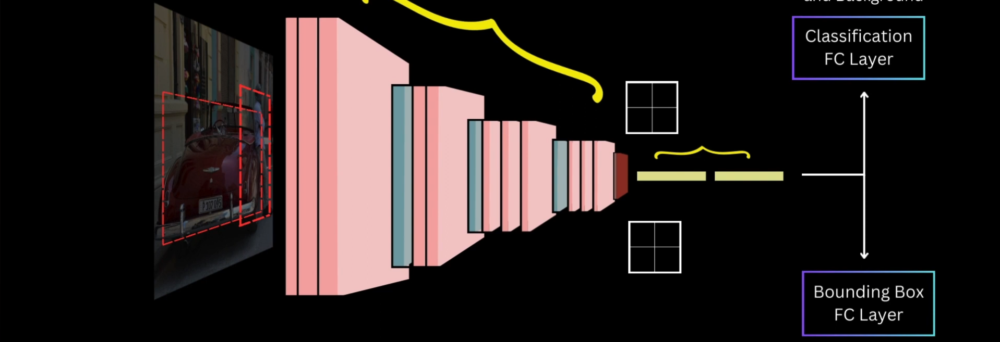

---

### 2.2. Giai đoạn chạy thực tế

#### a. Trạm Khởi tạo: Đề xuất vùng và Tạo Tháp ảnh (Selective Search & Multi-scale)

Trong quá trình thực chiến, các hàm Loss và Đáp án chuẩn bị gỡ bỏ, hệ thống không sử dụng Mini-batch mà nạp toàn bộ dữ liệu để quét sạch mục tiêu.

- **Sinh tọa độ tĩnh:** Thuật toán Selective Search chạy trên bức ảnh gốc để tạo ra khoảng 2.000 Hộp ứng viên.
- **Chiến lược Đa tỷ lệ (Image Pyramids - Tùy chọn):** Để đối phó với vật thể to nhỏ khác nhau, ảnh gốc được phóng to và thu nhỏ thành một "Tháp ảnh". Thay vì dùng chung một ảnh, thuật toán xét từng chiếc hộp trong số 2.000 hộp kia, ráp thử vào Tháp ảnh và chọn ra một phiên bản ảnh tối ưu nhất. Phiên bản được chọn là bức ảnh giúp diện tích của hộp ứng viên đó đạt xấp xỉ mức $224 \times 224$ pixel, đảm bảo AI luôn nhìn vật thể ở cự ly quen thuộc nhất.


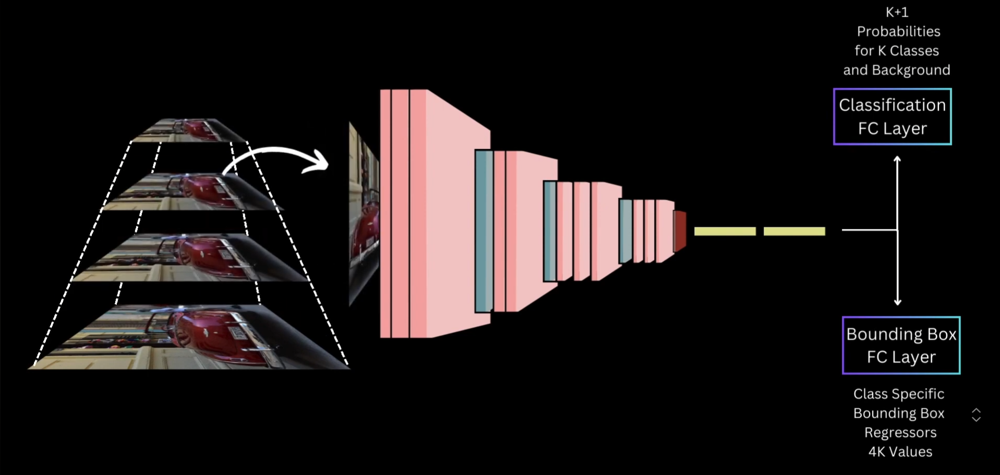


#### b. Trạm Trích xuất: Đun chảy một lần và RoI Pooling

- **Lan truyền xuôi tốc độ cao:** Các phiên bản ảnh được chọn từ Tháp ảnh được đẩy qua mạng CNN nguyên vẹn để sinh ra Bản đồ đặc trưng.
- **Trích xuất cục bộ:** 2.000 bộ tọa độ được chiếu lên Bản đồ đặc trưng. Lớp RoI Pooling lập tức cắt và ép 2.000 vùng ROI lộn xộn này thành các khối ma trận $7 \times 7$ đồng nhất.

#### c. Trạm Phán quyết: Chấm điểm và Nắn tọa độ song song (Softmax & Regressor)

- **Dàn phẳng và Tổng hợp:** 2.000 khối ma trận hóa thân thành các vector đặc trưng tĩnh và lao qua các lớp Kết nối đầy đủ (FC Layers). Trọng số của các lớp này lúc này đã được tôi luyện vô cùng sắc sảo.
- **Phán quyết song song:**
  - **Nhánh Phân loại (Softmax):** Xuất ra Xác suất % thuộc về từng danh mục cụ thể (ví dụ: 95% là Ô tô, 5% là Nền).
  - **Nhánh Nắn tọa độ (Regressor):** Xuất ra 4 hệ số $(dx, dy, dw, dh)$. Ngay lập tức, máy tính dùng toán học đảo ngược áp các hệ số này vào tọa độ hộp ứng viên ban đầu để dịch chuyển, ép chiếc hộp thô cứng ôm khít lấy hình dáng chiếc xe thực tế trên màn hình.

#### d. Trạm Dọn rác: Lọc Nền và Thuật toán NMS (Non-Maximum Suppression)

Hệ thống tiến hành dọn dẹp để xuất ra kết quả cuối cùng hoàn hảo nhất:

- **Lọc Nền:** Bất kỳ chiếc hộp nào bị Softmax kết luận là "Nền trống" (Background) với điểm số cao nhất sẽ bị vứt bỏ ngay lập tức.
- **Dọn dẹp cục bộ theo Nhãn (Per-class NMS):** Với các hộp chứa vật thể còn lại, hệ thống gom nhóm theo từng danh mục (ví dụ: gom tất cả hộp đoán là Ô tô lại với nhau).
  - **Bầu Vua:** Hộp có Điểm tự tin (Xác suất) cao nhất được phong làm Vua.
  - **Triệt tiêu trùng lặp:** Hộp Vua đo diện tích chồng lấp (IoU) với các hộp cấp thấp đè lên nó. Bất kỳ chiếc hộp nào có mức độ đè lấn quá lớn (vượt ngưỡng cho phép) sẽ bị xóa sổ, đảm bảo một chiếc xe chỉ có duy nhất một chiếc hộp khoanh trúng.
- **Đầu ra:** Bức ảnh cuối cùng hiện lên màn hình với những khung Bounding Box sắc nét, sạch sẽ và có độ tự tin cao nhất, hoàn tất quy trình suy luận mượt mà và vượt trội hoàn toàn về tốc độ so với thế hệ tiền nhiệm.
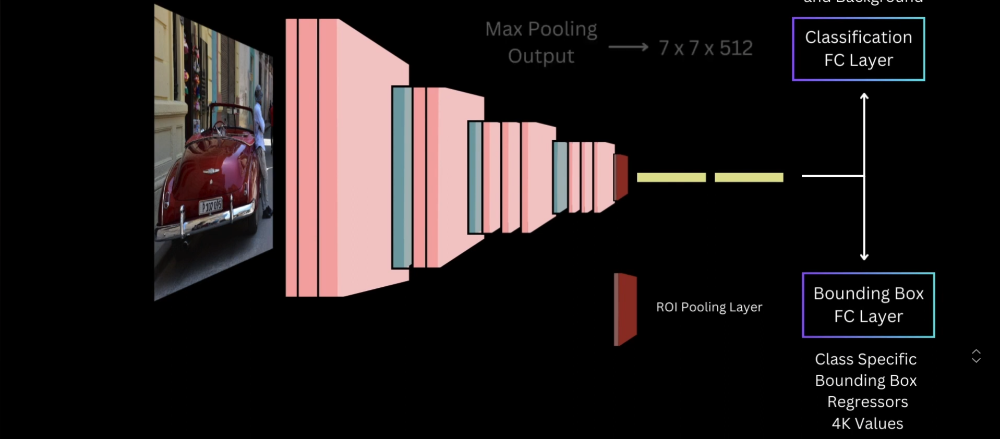

## 3. Faster RCNN

Sự ra đời của Faster R-CNN không chỉ là một bản nâng cấp, mà là một cuộc cách mạng thay đổi hoàn toàn cách máy tính nhìn nhận và bóc tách hình ảnh. Để hiểu được hệ thống này, chúng ta cần nhìn lại "nỗi đau" của những thế hệ đi trước và cách Faster R-CNN đã giải quyết chúng bằng một luồng tư duy khép kín.

#### a. Kỷ Nguyên Đứt Gãy và Sự Tích Hợp Toàn Diện

Trước khi Faster R-CNN xuất hiện, các mô hình như R-CNN đời đầu giống như một công xưởng chắp vá.

- Chúng phải nhờ cậy một thuật toán ngoại vi mang tên Selective Search để cắt ảnh mù quáng ra thành hàng ngàn mảnh nhỏ.
- Mạng nơ-ron chập (CNN) chỉ làm đúng một việc là trích xuất đặc trưng hình ảnh.
- Sau đó, dữ liệu lại bị đẩy ra ngoài cho một mô hình SVM để phân loại (chó, mèo) và một mô hình Linear Regression để nắn tọa độ.

Sự đứt gãy này khiến hệ thống cực kỳ chậm chạp và không thể tự học hỏi đồng bộ.

Bước nhảy vọt của Faster R-CNN là khai tử hoàn toàn Selective Search và SVM. Tác giả nhúng mọi công đoạn vào bên trong các lớp của mạng nơ-ron, tạo ra một cỗ máy End-to-End (Từ đầu đến cuối). Khi cỗ máy dự đoán sai, tín hiệu phạt sẽ chạy ngược (backpropagation) từ đầu ra cuối cùng về tận những lớp lọc ảnh đầu tiên, giúp toàn bộ hệ thống cùng nhau sửa sai trong một nhịp đập.

### b. Trái Tim Của Hệ Thống: Mạng Đề Xuất Vùng (RPN) – Nghệ Thuật Tự Trinh Sát Và Uốn Nắn

Để RPN có thể tự động phác thảo ra các bản nháp (Region Proposals) chính xác mà không cần con người hay thuật toán ngoại vi can thiệp, nó không chỉ cần một cấu trúc mạng thông minh mà còn cần một bộ quy tắc "tự chấm điểm và phạt" cực kỳ nghiêm ngặt ngay từ bên trong. Quá trình này là sự kết hợp hoàn hảo giữa Luồng dự đoán (Forward Pass), Quy tắc gán nhãn (Label Assignment) và Hàm mất mát (Loss Function).

**1. Cơ Chế Tiên Đoán (Luồng đi tới)**

Mọi thao tác trinh sát của RPN đều diễn ra trên Bản đồ đặc trưng (Feature Map).

- **Giăng lưới Khuôn mẫu (Anchor Boxes):** Tại mỗi điểm ảnh trên Feature Map, hệ thống ngầm định giăng ra 9 chiếc hộp khuôn mẫu (3 tỷ lệ $\times$ 3 kích thước) chiếu lên không gian ảnh gốc. Hàng chục ngàn Anchor Boxes này đứng im, tạo thành một mẻ lưới khổng lồ bao trùm toàn bộ bức ảnh.

 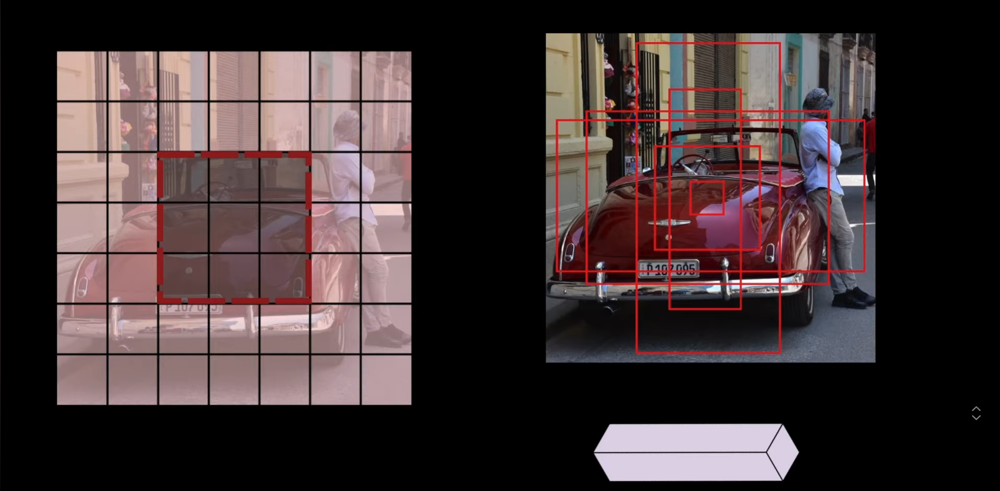
 
- **Đôi mắt $3\times3$ và Bộ não $1\times1$:** Một cửa sổ trượt $3\times3$ quét qua Feature Map để gom đặc trưng thị giác. Khối đặc trưng này lập tức đi qua lớp chập $1\times1$ để "bộ não" đưa ra phán đoán cho 9 Anchor Boxes tại vị trí đó:
  - **Nhánh Phân loại:** Xuất ra $2k$ điểm xác suất (dự đoán hộp này chứa Vật thể hay Nền trống).
  - **Nhánh Hồi quy:** Xuất ra $4k$ hệ số dịch chuyển tuyến tính (dự đoán cần kéo giãn, xê dịch hộp này bao nhiêu để ôm khít vật thể).



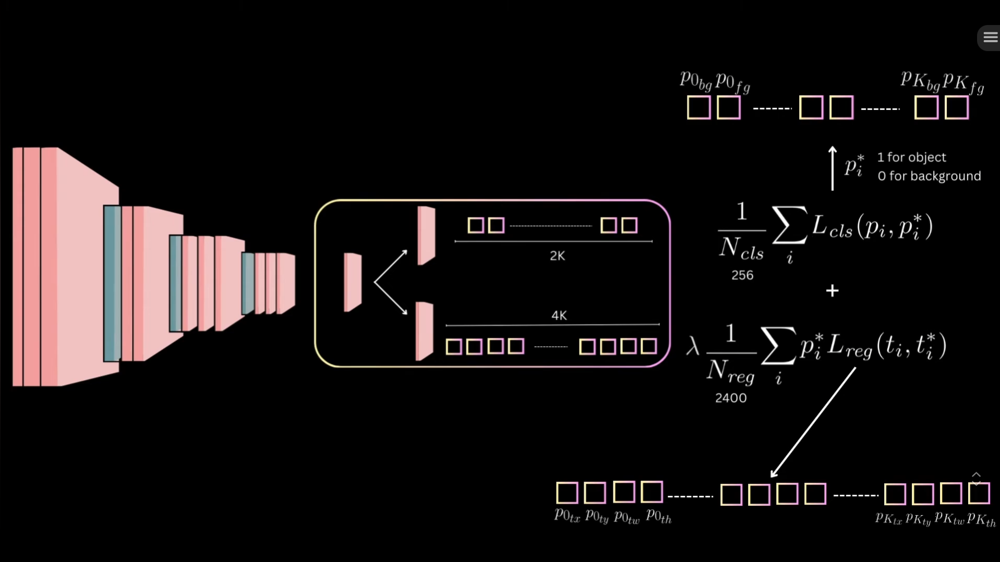



**2. Nghệ Thuật Gán Nhãn (Label Assignment) – Tìm Đáp Án Chuẩn**

Để biết các dự đoán trên là đúng hay sai, hệ thống cần một "Giám khảo". Vị giám khảo này chính là phép đo IoU (Intersection over Union – Độ chồng lấp) giữa hàng chục ngàn chiếc Anchor Boxes tĩnh kia và các hộp Đáp án chuẩn (Ground Truth) do con người khoanh từ trước.

Quá trình gán nhãn diễn ra vô cùng dứt khoát:

- *Gán nhãn Dương (Positive - $p_i^ = 1$):*\* Một Anchor Box được vinh danh là "chứa vật thể" nếu nó thỏa mãn một trong hai điều kiện: có chỉ số $IoU > 0.7$ với bất kỳ Đáp án chuẩn nào, HOẶC nó là chiếc hộp có IoU cao nhất với một Đáp án chuẩn cụ thể (để phòng trường hợp vật thể quá dị biệt, không hộp nào đạt mức 0.7).
- *Gán nhãn Âm (Negative - $p_i^ = 0$):*\* Một Anchor Box bị kết luận là "nền trống" nếu chỉ số IoU của nó $< 0.3$ với tất cả các Đáp án chuẩn.
- **Vùng xám phiền phức ($0.3 \le IoU \le 0.7$):** Những chiếc hộp khoanh lấp lửng, không rõ ràng này sẽ bị loại bỏ hoàn toàn khỏi quá trình huấn luyện. Tác giả không muốn đưa các dữ liệu mập mờ vào làm hệ thống bị bối rối trong giai đoạn học sơ khởi.

**3. Lồng Ghép Hàm Mất Mát (Multi-task Loss) – Chiếc Roi Phạt Của Hệ Thống**

Sau khi đã có "Nhãn" (Đáp án thực tế) và "Dự đoán" (Kết quả từ lớp $1\times1$), RPN sử dụng Hàm mất mát đa nhiệm để tính toán sai số và đánh roi (cập nhật trọng số) toàn hệ thống. Hàm Loss này là tổng hòa của hai thành phần:

> **Công thức tổng quát của RPN:**
>
> $$L(\\{p_i\\}, \\{t_i\\}) = \frac{1}{N\_{cls}} \sum_i L\_{cls}(p_i, p_i^\*) + \lambda \frac{1}{N\_{reg}} \sum_i p_i^\* L\_{reg}(t_i, t_i^\*)$$
>
> **Giải thích công thức:**
>
> - $i$: Chỉ số của một anchor trong mini-batch.
> - $p_i$: Xác suất dự đoán anchor $i$ là một vật thể.
> - $p_i^\*$: Nhãn thực tế ($1$ nếu là vật thể, $0$ nếu là nền trống).
> - $t_i$: Vector 4 tham số dự đoán dịch chuyển tọa độ của hộp.
> - $t_i^\*$: Vector 4 tham số dịch chuyển thực tế so với đáp án chuẩn.
> - $N\_{cls}, N\_{reg}$: Các hằng số chuẩn hóa (kích thước mini-batch và số lượng anchor tham gia).
> - $\lambda$: Trọng số cân bằng độ quan trọng giữa nhánh phân loại và hồi quy.

**Phạt lỗi Phân loại ($L\_{cls}$):**

Hệ thống so sánh điểm xác suất mà lớp $1\times1$ dự đoán ($p_i$) với nhãn thực tế ($p_i^\*$). Nếu một Anchor mang nhãn Dương ($p_i^\* = 1$) nhưng mạng lại dự đoán xác suất có vật thể rất thấp (ví dụ $p_i = 0.1$), hàm Cross-Entropy Loss sẽ vọt lên rất cao, tạo ra một hình phạt nặng nề ép các nơ-ron phải điều chỉnh lại cách nhìn nhận đặc trưng.

**Phạt lỗi Nắn Tọa độ ($L\_{reg}$) với "Cơ chế Công tắc":**

Mạng so sánh 4 hệ số dịch chuyển dự đoán ($t_i$) với 4 hệ số dịch chuyển thực tế cần thiết ($t_i^\*$) để nắn Anchor Box thành Đáp án chuẩn, sử dụng hàm Smooth L1 Loss.

Tuy nhiên, điểm thiên tài nằm ở việc hàm phạt này được nhân trực tiếp với biến chỉ báo $p_i^\*$.

- Nếu Anchor đó mang nhãn Dương ($p_i^\* = 1$), phép nhân giữ nguyên giá trị phạt: "Anh đã tìm đúng vật thể rồi, nhưng anh nắn hộp bị méo, anh bị phạt!".
- Nếu Anchor đó mang nhãn Âm ($p_i^\* = 0$), toàn bộ phần lỗi tọa độ bị nhân với 0 và triệt tiêu: "Đây chỉ là khoảng trời trống, anh nắn tọa độ sai cũng không sao, tôi không quan tâm!".

Cơ chế này ép RPN dồn toàn lực vào việc tinh chỉnh tọa độ cho những vùng thực sự có giá trị, bỏ qua các vùng nhiễu. Dưới sự uốn nắn liên tục của Hàm mất mát này, lớp chập $1\times1$ ngày càng điêu luyện. Khi quá trình huấn luyện hoàn tất, nó có thể tự tin biến hàng chục ngàn Anchor Boxes thô cứng thành các Hộp ứng viên (Region Proposals) ôm sát mục tiêu, sẵn sàng qua màng lọc NMS để gửi 2000 bản nháp xuất sắc nhất sang trạm Fast R-CNN.

### c. Quá Trình Huấn Luyện Fast R-CNN: Mài Giũa Vị Giám Khảo Tinh Anh

Nếu RPN (Mạng Đề xuất Vùng) được huấn luyện để làm một "trinh sát" giỏi tìm bản nháp, thì Fast R-CNN phải được huấn luyện để trở thành một "giám khảo" công tâm và sắc sảo. Quá trình dạy học cho Fast R-CNN cũng dựa trên cơ chế gán nhãn và phạt lỗi, nhưng với những tiêu chuẩn khắt khe hơn và quy mô phức tạp hơn (đa lớp thay vì nhị phân).

Dưới đây là 4 bước chi tiết trong quá trình huấn luyện vị giám khảo này:

**1. Sàng lọc hồ sơ (Mini-batch Sampling)**

Dù RPN gửi sang khoảng 2000 Hộp ứng viên (Region Proposals), hệ thống không lấy toàn bộ 2000 hộp này để tính toán Hàm mất mát trong một lần học (như vậy sẽ làm tràn bộ nhớ và thiên lệch dữ liệu).

Thay vào đó, trong mỗi bước học, hệ thống chỉ bốc ra một "lô nhỏ" (mini-batch) gồm khoảng 128 chiếc hộp ứng viên để dạy học. Điều quan trọng là tỷ lệ bốc mẫu được duy trì khắt khe: 25% là hộp chứa vật thể (Positive) và 75% là nền trống (Background) để tránh việc mạng bị "học lệch" do số lượng nền trống trong ảnh bao giờ cũng áp đảo.

**2. Phân định Nhãn (Label Assignment) – Tiêu chuẩn của Giám khảo**

Đích đến của Fast R-CNN là Hộp ứng viên, nên nó đem các Hộp ứng viên này đi đo $IoU$ trực tiếp với Đáp án chuẩn (Ground Truth). Luật chơi ở đây khác biệt hoàn toàn với RPN:

- **Nhãn Dương (Vật thể thực sự):** Một Hộp ứng viên được dán nhãn Vật thể nếu $IoU \ge 0.5$ với đáp án chuẩn. Mức $0.5$ này dễ thở hơn mức $0.7$ của RPN vì các hộp này đã được RPN nắn qua một lần, giờ cần Fast R-CNN tập trung phân loại chi tiết xem nó là con chó hay con mèo.
- **Nhãn Âm (Mẫu Âm tính khó - Hard Negatives):** Đây là điểm thiên tài của hệ thống! Một Hộp ứng viên bị dán nhãn Nền trống (Background) nếu nó có $IoU$ nằm trong khoảng từ $0.1$ đến dưới $0.5$. Tại sao không lấy các hộp cách xa tít tắp ($IoU < 0.1$)?

  Bởi vì những hộp $< 0.1$ là bầu trời, bãi cỏ – quá dễ để nhận ra. Những hộp từ $0.1$ đến $0.5$ thường là những chiếc hộp khoanh lẹm vào vật thể (ví dụ: chỉ khoanh trúng cái bánh xe thay vì cả chiếc xe). Bắt Fast R-CNN học trên các mẫu "khó nhằn" này ép nó phải cực kỳ tinh tường, không bao giờ báo động giả khi chỉ nhìn thấy một phần của vật thể.

**3. Hàm Mất Mát Đa Nhiệm (Multi-task Loss) của Fast R-CNN**

Giống như RPN, Fast R-CNN cũng bị phạt bởi hai cây roi, nhưng độ khó đã được nâng cấp:

> **Công thức tổng quát của Fast R-CNN:**
>
> $$L(p, u, t^u, v) = L\_{cls}(p, u) + \lambda [u \ge 1] L\_{reg}(t^u, v)$$
>
> **Giải thích công thức:**
>
> - $p$: Xác suất dự đoán đa lớp do lớp Softmax xuất ra (chó, mèo, ô tô...).
> - $u$: Nhãn lớp thực tế (với $u=0$ là nền trống, $u \ge 1$ là các danh mục vật thể).
> - $t^u$: 4 hệ số dịch chuyển tọa độ dự đoán tương ứng với lớp $u$.
> - $v$: 4 hệ số dịch chuyển thực tế từ Hộp ứng viên so với đáp án chuẩn.
> - $[u \ge 1]$: Hàm chỉ báo (Indicator function), bằng $1$ nếu thuộc lớp vật thể, bằng $0$ nếu là nền trống (tương đương biến $p_i^\*$ ở RPN).

**Lỗi Phân loại Đa lớp ($L\_{cls}$):** Thay vì chỉ đoán Có/Không, hàm phạt Cross-Entropy lúc này mở rộng ra $(C + 1)$ lớp (với $C$ là số lượng danh mục như chó, mèo, ô tô... và $1$ lớp cho Nền trống). Nếu chiếc hộp chứa con chó ($IoU \ge 0.5$ với đáp án con chó), nhưng lớp FC lại xuất ra xác suất cao cho con mèo, hàm Loss sẽ phạt cực nặng.

**Lỗi Nắn Tọa độ Tinh chỉnh ($L\_{reg}$):** Vẫn sử dụng hàm Smooth L1 Loss để phạt việc nắn lệch 4 hệ số $(x, y, w, h)$. Và quy tắc "cơ chế công tắc" vẫn được áp dụng nghiêm ngặt: Lỗi này chỉ được tính cho các Hộp ứng viên mang nhãn Dương (thuộc một lớp vật thể cụ thể). Nếu Hộp ứng viên đó được xác định là lớp "Nền trống", lỗi tọa độ lập tức bị triệt tiêu bằng 0.


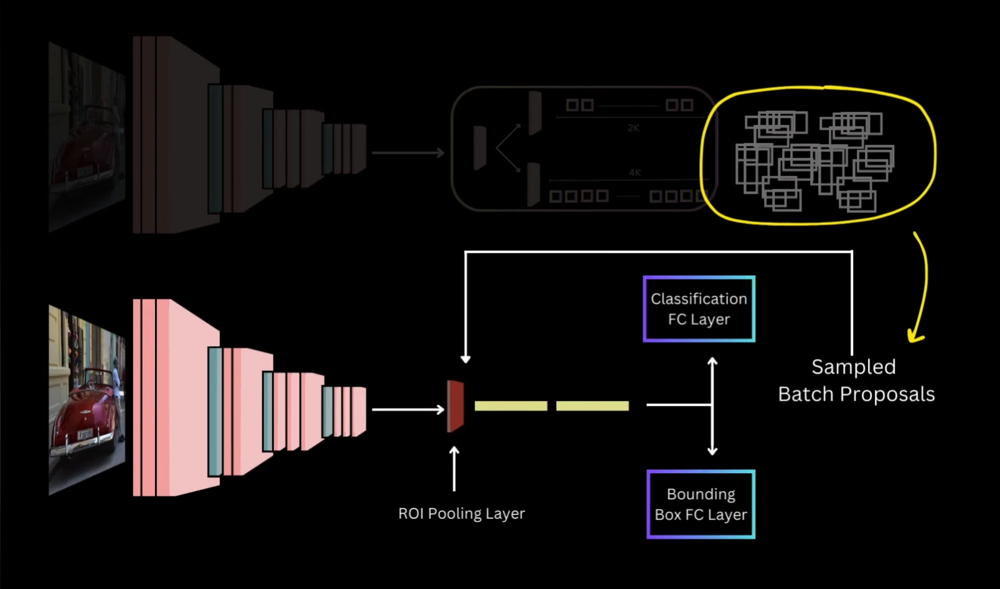


**4. Lan Truyền Ngược xuyên qua RoI Pooling (Backpropagation)**

Đây là thách thức kỹ thuật lớn nhất mà tác giả phải vượt qua. Khi hai hàm Loss tính ra điểm phạt ở tận cùng các lớp FC, tín hiệu phạt (đạo hàm) phải chạy ngược về để vặn chỉnh các lớp CNN đầu tiên.

Nhưng trên đường về, nó đụng phải "chiếc phễu" RoI Pooling – nơi vừa dùng Max Pooling để vứt bỏ rất nhiều pixel và chỉ giữ lại pixel lớn nhất.

Để giải quyết, RoI Pooling sử dụng một cơ chế ghi nhớ: trong lúc gộp ảnh, nó đánh dấu lại chính xác tọa độ của pixel chiến thắng (pixel lớn nhất). Khi tín hiệu phạt chạy ngược về, RoI Pooling chỉ truyền điểm phạt đó đúng vào pixel chiến thắng kia, các pixel từng bị loại bỏ sẽ nhận điểm phạt bằng 0. Nhờ sự thông luồng này, Fast R-CNN có thể ép mạng CNN nền tảng thay đổi trọng số, tạo nên cỗ máy End-to-End hoàn hảo.

**5. Đồng Bộ Hóa Hệ Thống: Đào Tạo Luân Phiên 4 Bước và Gộp Mạng CNN Nền Tảng**

Giấc mơ của tác giả là để RPN và Fast R-CNN xài chung một bộ xương sống CNN nhằm tối đa hóa tốc độ. **Việc gộp mạng CNN nền tảng (Shared CNN Backbone) chính là chìa khóa để triệt tiêu sự dư thừa tính toán, giúp cả hệ thống trích xuất đặc trưng hình ảnh đúng một lần duy nhất.** Tuy nhiên, nếu huấn luyện bừa bãi, trọng số của mạng này sẽ kéo lệch mạng kia. Tác giả thiết kế một quy trình luân phiên tinh tế:

- **Huấn luyện RPN độc lập:** Khởi tạo một mạng CNN số 1, cho RPN học cách tìm bản nháp.
- **Huấn luyện Fast R-CNN độc lập:** Lấy các bản nháp vừa tạo ở bước 1, đem đi dạy cho một mạng Fast R-CNN cùng với mạng CNN số 2 hoàn toàn mới. Mạng CNN số 2 lúc này học được cách nhìn chi tiết vật thể rất tốt.
- **Hợp nhất bộ não (Gộp mạng):** Lấy mạng CNN số 2 làm cốt lõi dùng chung. Đóng băng (Freeze) toàn bộ trọng số của nó lại. Bắt RPN dùng chung bộ não CNN này và chỉ cho phép cập nhật các lớp $3\times3$ và $1\times1$ đặc thù của riêng RPN. Sự gộp mạng này biến hai quy trình rời rạc thành một thể thống nhất chia sẻ toàn bộ các tầng chập.
- **Chốt hạ:** Tiếp tục đóng băng bộ não CNN chung, chỉ cho phép Fast R-CNN tinh chỉnh nốt các lớp FC của mình.


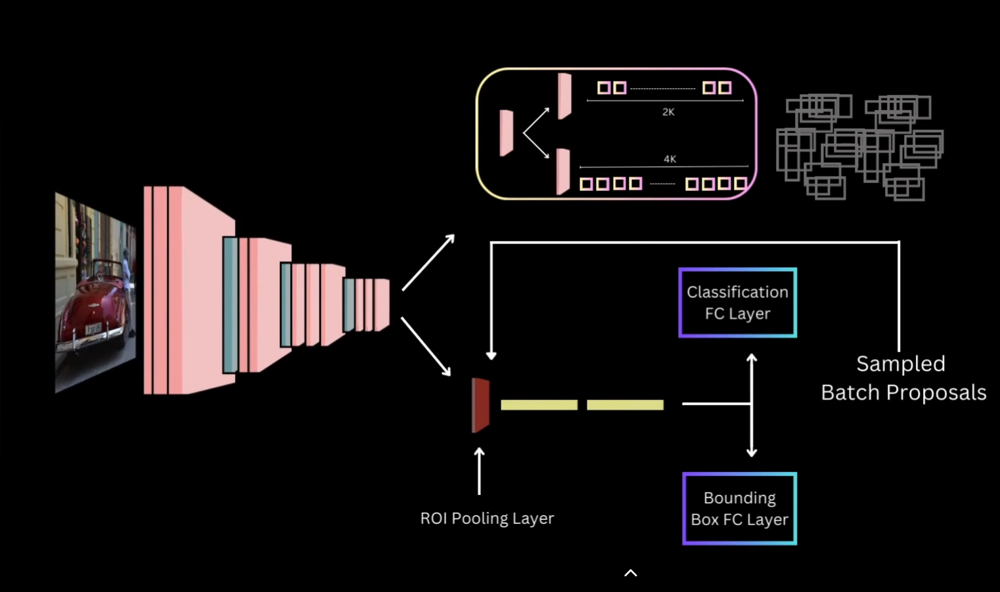


### d. Giai Đoạn Thực Chiến (Inference): Khi Cỗ Máy Rời Ghế Nhà Trường



**1. Trạm Trinh Sát RPN: Phác Thảo Nhanh Khung Ứng Viên**

Khi một bức ảnh mới được nạp vào, nó sẽ đi qua mạng CNN nền tảng để tạo ra Bản đồ đặc trưng (Feature Map). Kể từ đây, RPN bắt đầu màn trình diễn tốc độ cao của mình:

- **Dự đoán hàng loạt (Không cần đáp án):** Cửa sổ 3×3 và lớp 1×1 lướt qua toàn bộ Feature Map. Đối với mỗi chiếc Anchor Box trong số hàng chục ngàn chiếc được giăng ra, bộ trọng số (đã được huấn luyện chín muồi) ngay lập tức nhả ra:
  - Điểm xác suất (Objectness Score): Mức độ tự tin vùng này chứa vật thể (ví dụ: 0.95, 0.12,...).
  - Bốn hệ số dịch chuyển (dx, dy, dw, dh).
- **Biến hình (Bơm thịt vào khung xương):** Hệ thống lập tức lấy hàng chục ngàn chiếc Anchor Boxes tĩnh kia, cộng/nhân với 4 hệ số dịch chuyển vừa tính được. Các chiếc hộp vô hình ngay lập tức bị nắn lại, méo đi, co giãn ra để trở thành các Hộp ứng viên (Region Proposals) thực thụ. Bất kỳ chiếc hộp nào sau khi nắn mà bị tràn ra ngoài viền của bức ảnh đều bị cắt gọt lại hoặc loại bỏ.
- **Bộ lọc xếp hạng (Sorting):** Hệ thống không thể gửi hàng chục ngàn chiếc hộp sang màng tiếp theo vì quá nặng. Nó lấy "Điểm xác suất" ở bước 1 làm tiêu chí, xếp hạng toàn bộ các hộp từ cao xuống thấp và chỉ giữ lại một số lượng ưu tú nhất (thường là khoảng 6000 hộp đứng đầu).
- **Dọn dẹp bằng NMS (Non-Maximum Suppression):** Trong 6000 hộp này, có rất nhiều chiếc hộp đè lên nhau (ví dụ: 10 hộp cùng tranh nhau khoanh một con mèo). Thuật toán NMS sẽ can thiệp:
  - Nó lấy chiếc hộp có điểm xác suất cao nhất (ví dụ 0.98).
  - Nó xóa sạch tất cả các hộp xung quanh đè lên chiếc hộp đó (có mức độ chồng lấp lớn hơn một ngưỡng, ví dụ 0.7).

    Sau quá trình dọn dẹp khốc liệt này, RPN chốt lại một danh sách cuối cùng vô cùng sắc nét (thường chỉ giữ lại từ 300 đến 2000 hộp tùy cấu hình). Đây là thành phẩm chuyển sang trạm Fast R-CNN.

**2. Trạm Giám Khảo Fast R-CNN: Phán Quyết Cuối Cùng**

Khoảng 300 Hộp ứng viên tinh hoa nhất được gửi đến lớp RoI Pooling. Tại đây, chúng được chiếu lên Bản đồ đặc trưng, cắt ra và ép về chung kích thước 7×7.

- **Chốt hạ danh tính và nắn tọa độ lần 2:** Dữ liệu 7×7 chạy qua các lớp FC. Trọng số của lớp này giờ đây vô cùng sắc sảo. Nó nhìn vào từng hộp và lập tức xuất ra hai kết quả cuối cùng:
  - Xác suất đa lớp: Dự đoán % thuộc về từng danh mục (ví dụ: 90% là Ô tô, 8% là Xe tải, 2% là Nền).
  - Hệ số tọa độ lần cuối: 4 hệ số mới để nắn chiếc Hộp ứng viên kia ôm khít vào chiếc ô tô hơn nữa. (Đúng vậy, hệ thống nắn hộp tới 2 lần: RPN nắn thô, Fast R-CNN nắn tinh).
- **Lưới lọc NMS theo từng danh mục (Per-class NMS):** Sau khi nắn xong, chúng ta lại đối mặt với bài toán cũ: Nhiều hộp có thể vẫn cùng khoanh một chiếc ô tô. Hệ thống chạy thuật toán NMS một lần nữa, nhưng tinh vi hơn: nó gom các hộp dự đoán là "Ô tô" dọn dẹp với nhau, các hộp dự đoán là "Người" dọn dẹp với nhau.
- **Kết quả đầu ra:** Xóa bỏ toàn bộ các hộp bị dự đoán là "Nền trống" (Background). Những chiếc hộp sống sót cuối cùng, mang điểm xác suất cao nhất, ôm khít vật thể nhất chính là những khung chữ nhật (Bounding Boxes) được vẽ lên màn hình cho người dùng thấy, kết thúc trọn vẹn một quy trình nhận diện từ hình ảnh thô đến phán quyết cuối cùng chỉ trong một phần nhỏ của giây.
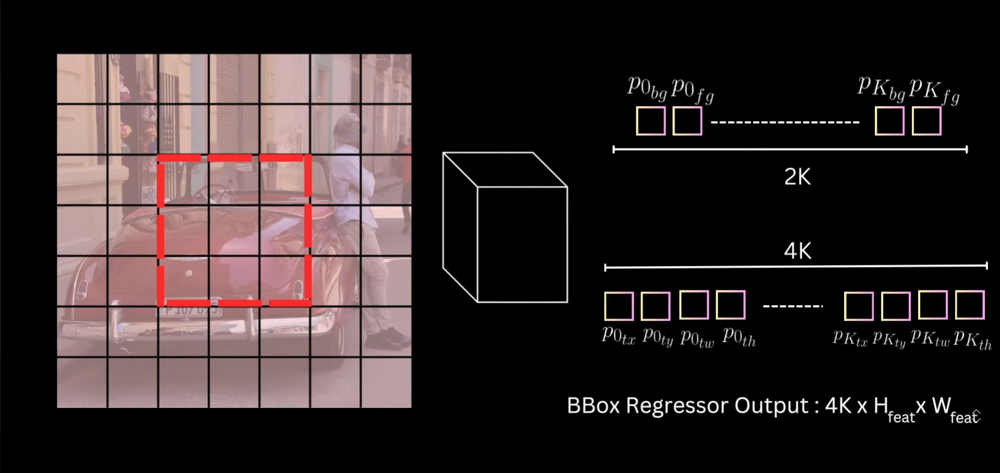

## 4. SSD

Trong giai đoạn huấn luyện, bài toán đặt ra cho hệ thống không phải là tự tưởng tượng ra một chiếc hộp, mà là học cách **"nắn chỉnh" các khuôn hình có sẵn** sao cho khớp với vật thể thực tế (**Ground Truth**), đồng thời nhận diện chính xác danh mục của vật thể đó.

### 4.1. Giai đoạn training

---

#### a. Tiền xử lý và Tăng cường dữ liệu (Data Augmentation)

Để một mô hình nhận diện trở nên bất khả chiến bại trước các biến động của môi trường thực tế, đặc biệt là kẻ thù mang tên "vật thể siêu nhỏ", dữ liệu thô phải trải qua các phép biến đổi quang học và hình học khắc nghiệt:

- **Điều chỉnh quang học:** Pha trộn ngẫu nhiên độ sáng, độ tương phản và bão hòa màu để mạng không bị phụ thuộc vào điều kiện ánh sáng.
- **Kỹ thuật Zoom-out (Mở rộng bối cảnh):** Đặt bức ảnh gốc vào một khung nền lớn (gấp 1 đến 4 lần) lấp đầy bằng nhiễu trung bình. Khi khung hình khổng lồ này được nén về $300 \times 300$, các vật thể bên trong sẽ teo nhỏ lại một cách cực đoan, ép các nơ-ron phải rèn luyện nhãn quan đối với các đối tượng li ti.
- **Cắt xén ngẫu nhiên (Random Crop):** Cắt ngẫu nhiên các vùng ảnh dựa trên chỉ số IoU nhằm tạo ra các góc nhìn khuyết thiếu (occlusion), dạy cho mô hình khả năng nhận diện ngay cả khi vật thể bị che khuất một phần.

---

#### Bước 2: Trích xuất Ma trận Đặc trưng Đa tỷ lệ (Multi-Scale Feature Extraction)

SSD không giới hạn tầm nhìn ở một trạm cuối cùng duy nhất. Bức ảnh đi qua mạng cơ sở **VGG-16** (đã gỡ bỏ các lớp Fully Connected) và tiếp tục đi qua một chuỗi các lớp Tích chập phụ trợ (**Extra Layers**).

Thay vì đập bẹp không gian, hệ thống chủ động mở ra 6 chốt chặn Feature Maps với độ phân giải suy giảm dần:

$$
38 \times 38,\quad
19 \times 19,\quad
10 \times 10,\quad
5 \times 5,\quad
3 \times 3,\quad
1 \times 1
$$

#### Nguyên lý phân cấp

- **Bản đồ $38 \times 38$:** Chứa lưới rất dày, lưu giữ lượng thông tin không gian lớn, chuyên xử lý vật thể nhỏ.
- **Bản đồ $1 \times 1$:** Có vùng cảm nhận (**receptive field**) lớn, chuyên xử lý vật thể lớn.

Sự phân công này giúp SSD phát hiện các vật thể ở nhiều kích thước khác nhau.

---

#### Bước 3: Khởi tạo Mạng lưới Hộp Mặc định tĩnh (Static Default Boxes)

Đây là một quy trình mang tính toán học, không phụ thuộc vào dữ liệu ảnh đầu vào. Tại mỗi ô vuông (**cell**) trên 6 Feature Maps, hệ thống dùng công thức để tạo sẵn các Default Boxes.

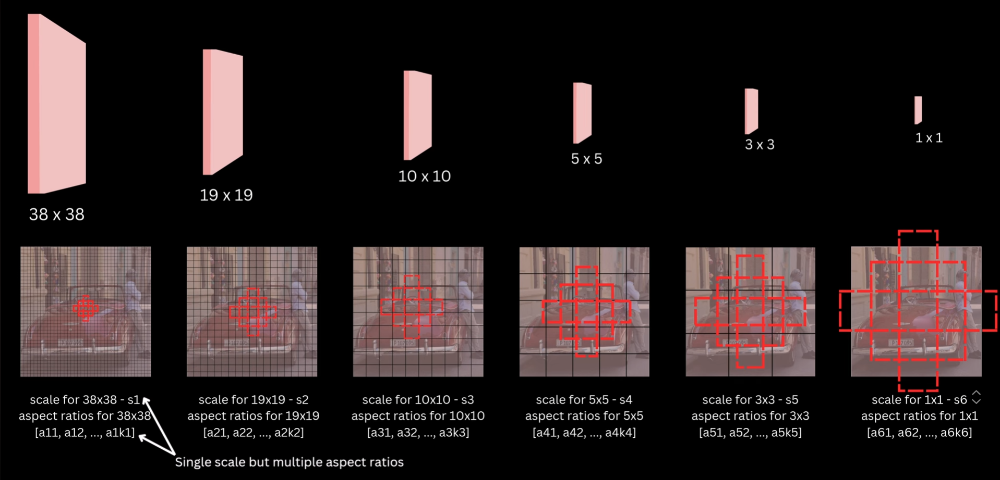

#### 1. Tọa độ tâm lưới

Tâm của các ô vuông trên Feature Map có kích thước $|f_k| \times |f_k|$ được xác định bằng:

$$
c_x = \frac{i + 0.5}{|f_k|}
$$

$$
c_y = \frac{j + 0.5}{|f_k|}
$$

với:

$$
i,j \in [0,|f_k|)
$$

là chỉ số dòng và cột của ô lưới tương ứng.

#### 2. Scale ($S_k$)

$S_k$ quy định kích thước gốc của chiếc hộp (**Default Box**) so với toàn bộ diện tích bức ảnh. Kích thước này tăng tuyến tính từ khoảng $0.1$ hoặc $0.2$ ở các trạm Feature Map nông (để bẫy vật thể nhỏ) lên đến khoảng $0.9$ ở các trạm Feature Map sâu (để bẫy vật thể chiếm tới $90\%$ khung hình).

Để đảm bảo các chiếc hộp phình to đều đặn qua từng trạm, SSD sử dụng công thức nội suy tuyến tính để tính $S_k$ cho Feature Map thứ $k$:

$$
s_k = s_{min} + \frac{s_{max} - s_{min}}{m - 1}(k - 1)
$$

Trong đó:

- $m$: Tổng số lượng Feature Maps tham gia dự đoán (trong kiến trúc chuẩn của SSD, $m = 6$).
- $k$: Số thứ tự của Feature Map hiện tại ($k \in [1,m]$).
- $s_{min}$ và $s_{max}$: Giới hạn tỷ lệ thu phóng, thường được đặt là $0.2$ và $0.9$. (Lớp đầu tiên thường có tỷ lệ ngoại lệ $s_1 = 0.1$ hoặc $0.2$.)
#### 3. Aspect Ratio ($a_r$)

**Tham số $a_r$ (Aspect Ratio - Tỷ lệ khung hình)**

Vật thể trong thực tế mang nhiều hình dáng khác nhau (người thì cao gầy, xe buýt thì bè ngang). Tại cùng một mức độ lớn $S_k$, hệ thống sinh ra nhiều chiếc hộp với tỷ lệ chiều rộng chia chiều cao khác nhau, được định nghĩa bởi:

$$
a_r \in \left\{1, 2, 0.5, 3, \frac{1}{3}\right\}
$$

Dựa vào hai tham số này, chiều rộng ($w$) và chiều cao ($h$) thực tế của chiếc hộp được tính bằng công thức:

- **Chiều rộng:**
  $$
  w = S_k\sqrt{a_r}
  $$

- **Chiều cao:**
  $$
  h = \frac{S_k}{\sqrt{a_r}}
  $$

Cấu trúc căn bậc hai ($\sqrt{a_r}$) trong công thức là một thiết kế toán học tinh tế. Khi bạn nhân chiều rộng với chiều cao ($w \times h$), các phần tử căn bậc hai sẽ triệt tiêu lẫn nhau, khiến diện tích của mọi chiếc hộp luôn được bảo toàn cố định ở mức $S_k^2$, bất kể chúng bị nắn thành hình chữ nhật đứng ($a_r = 0.5$) hay hình chữ nhật ngang ($a_r = 2$).

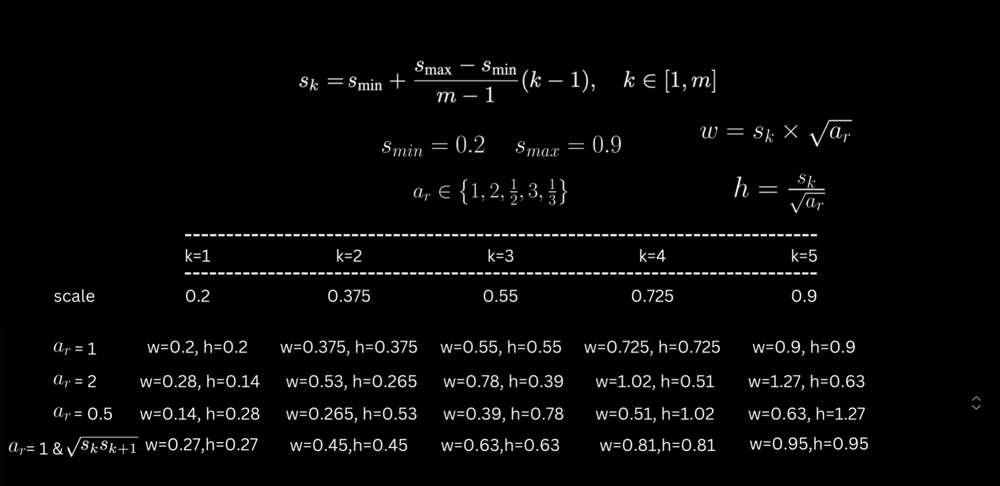
---

#### Bước 4: Quét Bộ lọc Tích chập sinh Dự đoán (Convolutional Predictions)

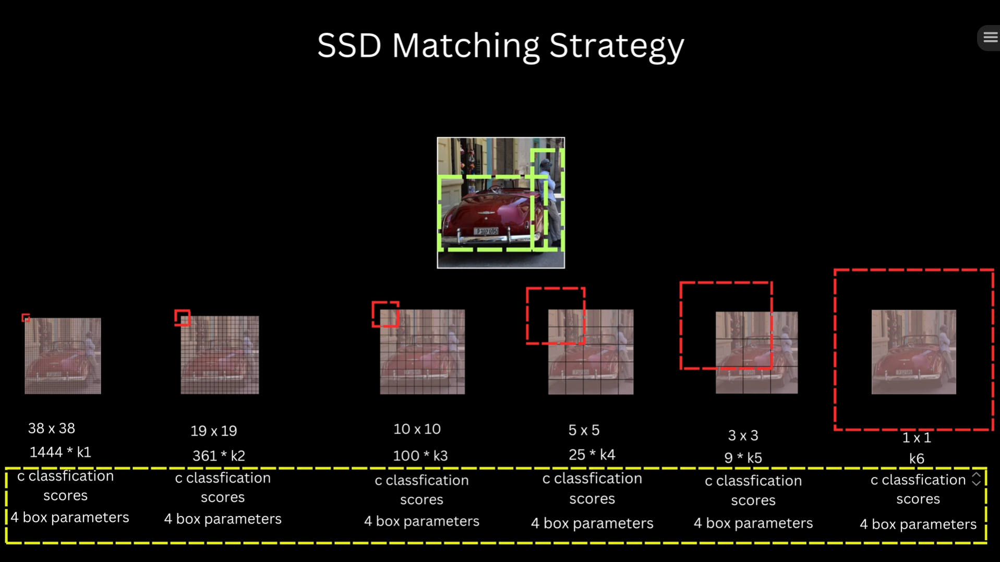

#### 1. Cấu trúc tham số của một hộp

Mỗi Default Box cần hai nhóm thông tin:

- **Không gian (4 tham số):** $(t_x,t_y,t_w,t_h)$.
- **Phân loại ($C$ tham số):** Xác suất của các lớp vật thể cộng thêm lớp Background.

Ví dụ với 20 lớp vật thể:

$$
C=21
$$

Do đó, mỗi hộp cần:

$$
4+C
$$

tham số.

Với $C=21$:

$$
4+21=25
$$

tham số.

#### 2. Khuếch đại dữ liệu tại một ô lưới

Tại mỗi ô trên Feature Map, SSD sử dụng $k$ Default Boxes, thường:

$$
k=6
$$

Do đó:

$$
6\times25=\mathbf{150}
$$

tham số độc lập tại một cell.

#### 3. Bộ lọc Tích chập song song

Để sinh ra đồng thời 150 giá trị, lớp tích chập sử dụng 150 bộ lọc đầu ra tương ứng.

- 25 bộ lọc đầu tiên → dự đoán cho Box 1.
- 25 bộ lọc tiếp theo → dự đoán cho Box 2.
- ...
- 25 bộ lọc cuối → dự đoán cho Box 6.

Do đó, độ sâu của lớp tích chập được xác định bởi:

$$
\boxed{\text{Depth}=k\times(C+4)}
$$

Thiết kế này cho phép mạng nơ-ron dự đoán trực tiếp các thông số trên Feature Map, loại bỏ các lớp Fully Connected cồng kềnh và bảo toàn cấu trúc không gian.

---

### Bước 5: Chiến lược Khớp nối Hộp (Matching Strategy)

Hệ thống đối chiếu **8732 Default Boxes** với Ground Truth.

Đầu tiên, tính chỉ số IoU giữa các Default Boxes và vật thể thực tế.

- Hộp có IoU lớn nhất với Ground Truth hoặc có:

$$
IoU>0.5
$$

được gán nhãn **Dương tính (Foreground)**.

- Các hộp có:

$$
IoU\leq0.5
$$

được gán nhãn **Âm tính (Background)**.

Các hộp Positive sẽ được sử dụng để học cách định vị và phân loại vật thể.

---

### Bước 6: Lọc Mẫu Âm Cứng (Hard Negative Mining)

Số lượng hộp Background thường lớn hơn rất nhiều so với hộp Positive.

Nếu sử dụng toàn bộ Negative, mô hình có thể có xu hướng dự đoán mọi thứ là Background.

Để giải quyết vấn đề này, SSD:

1. Tính Confidence Loss của các hộp Negative.
2. Chọn các Negative khó nhất.
3. Giữ lại các mẫu có lỗi cao nhất.
4. Giới hạn tỷ lệ:

$$
\boxed{\text{Negative:Positive}=3:1}
$$

Các mẫu Background dễ phân loại sẽ bị loại khỏi quá trình huấn luyện.

---

### Bước 7: Tối ưu hóa bằng Hàm Mất Mát Đa Nhiệm (Multi-task Loss Function)

Hàm mất mát SSD buộc mạng giải quyết đồng thời hai nhiệm vụ:

- **Phân loại (Classification).**
- **Định vị (Localization).**

Hàm mất mát tổng thể:

$$
Loss=\frac{1}{N}(loss_{cls}+loss_{loc})
$$

Trong đó $N$ là số lượng hộp Positive được khớp.

---

#### 7.1. Phân hệ Phân loại ($loss_{cls}$ - Confidence Loss)

Hàm phân loại sử dụng **Softmax Cross-Entropy**:

$$
loss_{cls}
=
\underbrace{
-\sum_{i\in Pos}^{N}
x_{ij}^{p}\log(\hat{c}_i^p)
}_{loss_{cls}(pos)}
\quad
\underbrace{
-\sum_{i\in Neg}
\log(\hat{c}_i^0)
}_{loss_{cls}(neg)}
$$

#### Cơ chế đánh giá chỉ báo

Biến:

$$
x_{ij}^{p}\in\{1,0\}
$$

hoạt động như một công tắc:

- $x_{ij}^{p}=1$: hộp $i$ khớp với Ground Truth $j$ thuộc lớp $p$.
- $x_{ij}^{p}=0$: không có sự khớp tương ứng.

#### Phạt hộp Dương tính

Thành phần:

$$
loss_{cls}(pos)
=
-\sum_{i\in Pos}^{N}
x_{ij}^{p}\log(\hat{c}_i^p)
$$

phạt mô hình khi xác suất dự đoán đúng lớp quá thấp.

Mục tiêu là:

$$
\hat{c}_i^p\rightarrow1
$$

#### Phạt hộp Âm tính

Thành phần:

$$
loss_{cls}(neg)
=
-\sum_{i\in Neg}
\log(\hat{c}_i^0)
$$

tập trung vào các Hard Negative và phạt mô hình khi dự đoán sai Background.

---

#### 7.2. Phân hệ Định vị ($loss_{loc}$ - Localization Loss)

Hàm định vị sử dụng **Smooth L1 Loss** và chỉ áp dụng cho các hộp Positive:

$$
loss_{loc}
=
\sum_{i\in Pos}^{N}
\sum_{m\in\{cx,cy,w,h\}}
\text{smooth}_{L1}
(l_i^m-\hat{g}_j^m)
$$

Trong đó:

- $l_i^m$: giá trị dự đoán.
- $\hat{g}_j^m$: Ground Truth sau khi mã hóa.
- $m\in\{cx,cy,w,h\}$: bốn tham số không gian.

#### Cơ chế mã hóa tọa độ (Bounding Box Regression)

Ground Truth không được học trực tiếp dưới dạng tọa độ tuyệt đối mà được mã hóa dựa trên Default Box.

#### Sai lệch tâm

$$
\hat{g}_j^{cx}
=
\frac{g_j^{cx}-d_i^{cx}}{d_i^w}
$$

$$
\hat{g}_j^{cy}
=
\frac{g_j^{cy}-d_i^{cy}}{d_i^h}
$$

#### Sai lệch kích thước

$$
\hat{g}_j^w
=
\log\left(
\frac{g_j^w}{d_i^w}
\right)
$$

$$
\hat{g}_j^h
=
\log\left(
\frac{g_j^h}{d_i^h}
\right)
$$

---

### 4.2. Giai đoạn thực tế 

Khi ma trận trọng số đã được huấn luyện, SSD bước vào môi trường thực tế.

Lúc này:

- Không còn Ground Truth.
- Không còn Loss.
- Không còn Lan truyền ngược.
- Hệ thống chỉ thực hiện **Forward Pass**.

---

#### Bước 1: Tiền xử lý Ảnh (Input Preprocessing)

Ảnh đầu vào được đưa về kích thước phù hợp với kiến trúc, ví dụ:

$$
300\times300
$$

Sau đó thực hiện **Mean Subtraction** để chuẩn hóa dữ liệu đầu vào.

---

#### Bước 2: Lan Truyền Tiến (Forward Pass)

Ảnh đi qua:

$$
Input
\rightarrow VGG\text{-}16
\rightarrow Extra\ Layers
$$

Mạng tạo ra 6 Feature Maps với các độ phân giải khác nhau.

---

#### Bước 3: Dự đoán Tích chập (Convolutional Detection)

Tại các Feature Maps, các bộ lọc tích chập thực hiện dự đoán cho toàn bộ:

$$
8732
$$

Default Boxes.

Mỗi hộp chứa:

- 4 thông số nắn chỉnh:

$$
(t_x,t_y,t_w,t_h)
$$

- Điểm số xác suất của các lớp vật thể.

---

#### Bước 4: Giải mã Tọa độ Không gian (Decode Bounding Boxes)

Hệ thống sử dụng 8732 Default Boxes ban đầu làm tham chiếu.

Các thông số:

$$
(t_x,t_y,t_w,t_h)
$$

được sử dụng để giải mã Bounding Box.

Quá trình này biến các biến số tương đối thành tọa độ tuyệt đối:

$$
(x_{min},y_{min},x_{max},y_{max})
$$

Nếu tọa độ vượt ra ngoài biên ảnh, thuật toán **Clamp** sẽ đưa chúng về phạm vi hợp lệ.

---

#### Bước 5: Lọc Ngưỡng Tin Cậy (Confidence Thresholding)

Các điểm số được đưa qua **Softmax** để chuyển thành xác suất.

Những hộp có Confidence thấp hơn ngưỡng, ví dụ:

$$
0.05
$$

sẽ bị loại bỏ.

Nhờ đó, số lượng ứng viên giảm đáng kể so với 8732 hộp ban đầu.

---

#### Bước 6: Triệt tiêu Không Cực Đại theo Lớp (Class-wise NMS)

Sau bước lọc Confidence, nhiều Bounding Box vẫn có thể cùng dự đoán một vật thể.

SSD thực hiện **NMS theo từng lớp**.

#### Quy trình

1. Phân tách các Bounding Box theo từng lớp.
2. Chọn hộp có Confidence cao nhất.
3. Tính IoU giữa hộp được chọn và các hộp còn lại.
4. Loại bỏ các hộp có:

$$
IoU\geq0.45
$$

5. Lặp lại cho đến khi loại bỏ các dự đoán trùng lặp.

Kết quả cuối cùng gồm:

- **Bounding Box**
- **Nhãn lớp**
- **Confidence Score**

cho từng vật thể được phát hiện.

---

#### KẾT LUẬN

Kiến trúc SSD là một mô hình Object Detection kết hợp:

- **Static Default Boxes**
- **Multi-Scale Feature Maps**
- **Convolutional Prediction**
- **Bounding Box Regression**
- **Hard Negative Mining**
- **Multi-task Loss**
- **Non-Maximum Suppression (NMS)**

Bằng cách sử dụng nhiều Feature Maps ở các độ phân giải khác nhau và loại bỏ các lớp Fully Connected cồng kềnh, SSD có thể xử lý các vật thể ở nhiều kích thước đồng thời duy trì tốc độ suy luận cao.

Toàn bộ pipeline có thể khái quát:

$$
\boxed{
Input
\rightarrow
Feature\ Extraction
\rightarrow
Default\ Boxes
\rightarrow
Convolutional\ Prediction
\rightarrow
Decode
\rightarrow
Confidence\ Threshold
\rightarrow
NMS
\rightarrow
Detection
}
$$

## 5. YoLov1


Sự ra đời của YOLO (You Only Look Once) đánh dấu một bước ngoặt về tư duy trong lĩnh vực thị giác máy tính. Khác với các hệ thống hai giai đoạn (Two-Stage) cồng kềnh phải phụ thuộc vào các thuật toán trích xuất vùng đề xuất ngoại vi, YOLO tái định nghĩa toàn bộ quá trình phát hiện vật thể thành một bài toán hồi quy (Regression) khép kín. Dưới đây là kiến trúc giải phẫu chi tiết của toàn bộ pipeline huấn luyện YOLOv1.
### 5.1. Giai đoạn huấn luyện
#### a. Giai Đoạn Tiền Huấn Luyện (Pre-training) và Tái Cấu Trúc Khung Xương (Backbone)

Để cỗ máy có thể định vị không gian một cách chính xác, trước tiên nó phải sở hữu một "nhãn quan" sắc bén để nhận diện các đặc trưng thị giác cốt lõi (đường nét, hình khối, kết cấu).

- **Hấp thụ tri thức nền tảng:** Mạng nơ-ron cơ sở (thường là kiến trúc tương tự GoogLeNet với 20 lớp chập đầu tiên) được tiền huấn luyện trên bộ dữ liệu khổng lồ ImageNet. Ở giai đoạn này, đầu vào là các bức ảnh độ phân giải $224 \times 224$ và tác vụ duy nhất là phân loại hình ảnh (Image Classification).
- **Phẫu thuật tái cấu trúc:** Sau khi mô hình đạt độ bão hòa về khả năng trích xuất đặc trưng, hệ thống tiến hành loại bỏ các lớp nơ-ron chuyên biệt cho việc phân loại ở phần đuôi.
- **Lắp ráp module nhận diện:** Bổ sung thêm 4 lớp Tích chập (Convolutional Layers) và 2 lớp Kết nối hoàn toàn (Fully Connected Layers) đặc thù của YOLO. Lúc này, mạng đã sẵn sàng chuyển đổi từ việc trả lời câu hỏi "Trong ảnh có gì?" sang "Vật thể ở đâu và là gì?".

#### b. Tiền Xử Lý Dữ Liệu và Chuẩn Hóa Không Gian Mục Tiêu (Target Normalization)

Hàm mất mát của mạng nơ-ron hoạt động tối ưu nhất trên không gian số thực hẹp. Do đó, toàn bộ dữ liệu nhãn chuẩn (Ground Truth) do con người gán phải được dịch sang ngôn ngữ toán học chuẩn hóa.

- **Khuếch đại không gian ảnh:** Kích thước ảnh đầu vào được nâng từ $224 \times 224$ lên $448 \times 448$. Nhận diện không gian đòi hỏi thông tin điểm ảnh chi tiết hơn nhiều so với phân loại thuần túy.
- **Chiến lược chia lưới $S \times S$:** Bức ảnh được chia thành một ma trận lưới ảo, mặc định $S = 7$.
- **Luật gán nhãn "Chính chủ":** Thuật toán quét qua tọa độ tâm của các Đáp án chuẩn. Nếu tâm của vật thể rơi trúng vào ô lưới $i$, duy nhất ô lưới đó mang biến chỉ báo $\mathbb{1}_i^{obj} = 1$ (phải chịu trách nhiệm phát hiện vật thể này). Toàn bộ các ô còn lại bị gán nhãn phông nền $\mathbb{1}_i^{noobj} = 1$.
- **Chuẩn hóa hệ tọa độ (0-1):**
  - Tọa độ tâm $(x, y)$ được tính toán dưới dạng độ lệch (offset) tương đối so với góc trên cùng bên trái của chính ô lưới chứa nó.
  - Kích thước chiều rộng và chiều cao $(w, h)$ được chuẩn hóa bằng cách chia cho tổng chiều rộng và chiều cao của toàn bộ bức ảnh.

#### c. Lan Truyền Tiến (Forward Pass) – Trích Xuất và Phác Thảo

Đây là luồng chảy dữ liệu một chiều biến các điểm ảnh thô thành một ma trận số học định lượng.

- **Trích xuất độ sâu:** Ảnh $448 \times 448$ đi qua chuỗi các lớp Tích chập và Gộp (Max Pooling), liên tục bị nén lại về không gian nhưng mở rộng về độ sâu đặc trưng, tạo ra một khối Tensor trung gian kích thước $7 \times 7 \times 1024$.
- **Duỗi thẳng và tính toán tuyến tính:** Khối Tensor này được đập bẹp (Flatten) thành một vector 1D và đẩy qua lớp Fully Connected với hàng triệu phép nhân ma trận trọng số.
- **Khối Tensor Chốt hạ:** Ở lớp cuối cùng, mạng định hình lại và "nhả" ra một khối Tensor có kích thước $S \times S \times (B \times 5 + C)$. Với YOLOv1, cấu hình chuẩn là lưới $7 \times 7$, $B=2$ (hộp dự đoán mỗi ô) và $C=20$ (lớp danh mục). Do đó, đầu ra là một khối $7 \times 7 \times 30$, chứa toàn bộ tọa độ dự đoán, độ tự tin và xác suất phân loại.


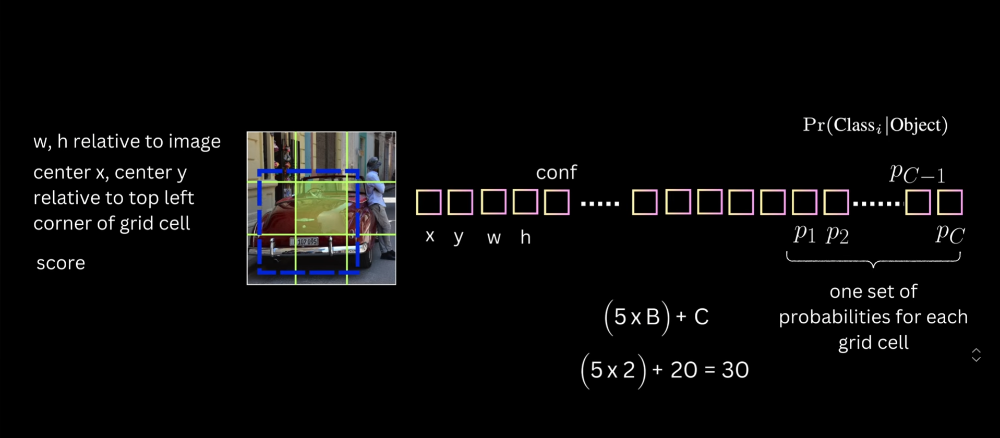


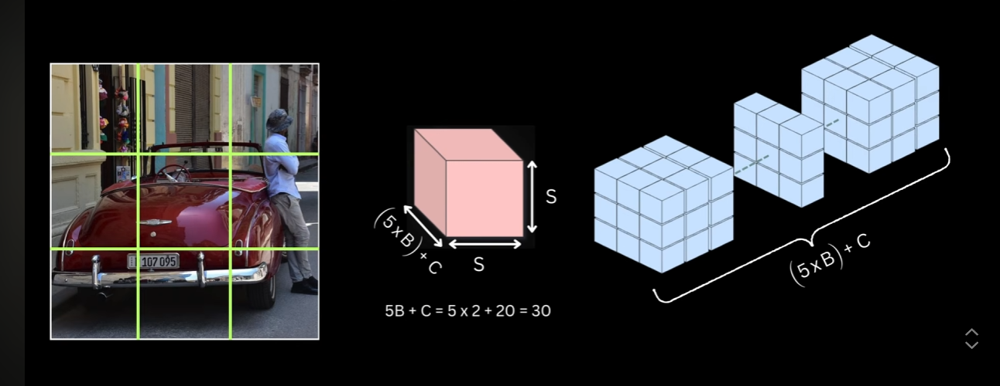


#### d. Chiến Lược Phân Công Trách Nhiệm (Target Assignment & IOU Evaluation)

Để tránh tình trạng "nhiều thầy thối ma" – nơi nhiều hộp dự đoán cùng tranh giành học cách khoanh một vật thể gây nhiễu loạn trọng số, YOLO áp dụng cơ chế đánh giá IOU khắt khe.

- Tại ô lưới có vật thể ($\mathbb{1}_i^{obj} = 1$), mạng phác thảo ra $B=2$ chiếc hộp. Thuật toán đo lường chỉ số IOU (Intersection over Union) giữa 2 hộp này với Đáp án chuẩn.
- Chiếc hộp có IOU cao hơn lập tức được kích hoạt công tắc $\mathbb{1}_{ij}^{obj} = 1$, chính thức trở thành "Hộp chịu trách nhiệm" (Responsible Box). Chiếc hộp thua cuộc bị đánh tụt xuống hạng phông nền ($\mathbb{1}_{ij}^{noobj} = 1$).

#### e. Hàm Mất Mát Đa Nhiệm (Multi-task Loss Function) – Trái Tim Của Hệ Thống

Sự vĩ đại của YOLOv1 nằm ở việc kết hợp 3 mục tiêu: Nắn tọa độ, Đánh giá độ tự tin và Phân loại danh mục vào chung một phương trình Hồi quy Bình phương (Sum-Squared Error) duy nhất.

$$
\begin{aligned}
\text{Loss} = &\lambda_{coord} \sum_{i=0}^{S^2} \sum_{j=0}^{B} \mathbb{1}_{ij}^{obj}
\left[ (x_i - \hat{x}_i)^2 + (y_i - \hat{y}_i)^2 \right] \\
&+ \lambda_{coord} \sum_{i=0}^{S^2} \sum_{j=0}^{B} \mathbb{1}_{ij}^{obj}
\left[ (\sqrt{w_i} - \sqrt{\hat{w}_i})^2 + (\sqrt{h_i} - \sqrt{\hat{h}_i})^2 \right] \\
&+ \sum_{i=0}^{S^2} \sum_{j=0}^{B} \mathbb{1}_{ij}^{obj}
(C_i - \hat{C}_i)^2 \\
&+ \lambda_{noobj} \sum_{i=0}^{S^2} \sum_{j=0}^{B} \mathbb{1}_{ij}^{noobj}
(C_i - \hat{C}_i)^2 \\
&+ \sum_{i=0}^{S^2} \mathbb{1}_{i}^{obj}
\sum_{c \in classes} (p_i(c) - \hat{p}_i(c))^2
\end{aligned}
$$

### **Phân tích chi tiết 5 mảnh ghép của Hàm Mất Mát:**

- **Kiểm soát Mất cân bằng dữ liệu (Imbalance Tuning):** Vì phần lớn bức ảnh là nền trống, hệ thống sử dụng trọng số $\lambda_{noobj} = 0.5$ để giảm một nửa điểm phạt đối với các hộp phông nền, tránh việc cỗ máy bị áp đảo và có xu hướng đoán mọi thứ là nền. Ngược lại, $\lambda_{coord} = 5$ được sử dụng để khuếch đại gấp 5 lần sức nặng của các hình phạt định vị không gian.
- **Phạt Tọa độ tâm (Dòng 1):** Tính bình phương khoảng cách giữa tâm dự đoán và tâm thực tế. Công tắc $\mathbb{1}_{ij}^{obj}$ đảm bảo chỉ chiếc hộp chịu trách nhiệm mới bị phạt.
- **Phạt Kích thước (Dòng 2 - Thủ thuật Căn bậc hai):** Tác giả sử dụng căn bậc hai ($\sqrt{w}, \sqrt{h}$) thay vì giá trị thô để tính sai số. Đặc tính của hàm căn bậc hai giúp phóng đại sai lệch ở các vật thể có kích thước nhỏ. Việc lệch 10 pixel ở một con kiến sẽ tạo ra điểm phạt nặng nề hơn rất nhiều so với lệch 10 pixel ở một chiếc xe tải.
- **Phạt Độ tự tin Hộp đích (Dòng 3):** Ép độ tự tin dự đoán ($C_i$) của hộp chịu trách nhiệm phải tiến sát về giá trị lý tưởng $\hat{C}_i$ (chính là chỉ số IOU thực tế của nó với Đáp án chuẩn).
- **Quét sạch Báo động giả (Dòng 4):** Áp dụng cho toàn bộ các hộp phông nền hoặc hộp thua cuộc ($\mathbb{1}_{ij}^{noobj}$). Mục tiêu lý tưởng của chúng là $\hat{C}_i = 0$. Bất kỳ dự đoán nào lớn hơn 0 đều phải chịu phạt nhẹ.
- **Phạt Lỗi Phân loại (Dòng 5):** Đo lường bình phương sai lệch giữa xác suất dự đoán $p_i(c)$ và vector One-hot thực tế. Chú ý rằng hàm này chỉ lặp qua chỉ số ô lưới $i$ ($\mathbb{1}_{i}^{obj}$), không quan tâm đến từng chiếc hộp $j$, phản ánh đúng bản chất: bộ xác suất danh mục thuộc về thẩm quyền chung của cả ô lưới.

#### g. Lan Truyền Ngược (Backpropagation) và Cập Nhật Trọng Số

- Tổng điểm phạt (Total Loss) từ phương trình trên đóng vai trò là "chiếc roi" định hướng toàn bộ mạng nơ-ron.
- Thuật toán tối ưu hóa (ví dụ: SGD với Momentum) tính toán đạo hàm của Tổng sai số theo từng trọng số trong mạng nơ-ron.
- Tín hiệu trừng phạt này truyền ngược (Backpropagate) xuyên qua các lớp Fully Connected về tận các bộ lọc Tích chập đầu tiên. Trọng số nào làm tăng sai số sẽ bị ép giảm xuống, trọng số nào giúp hộp khít hơn sẽ được tăng cường.
- Chu trình từ Giai đoạn 2 đến Giai đoạn 6 được lặp đi lặp lại qua nhiều kỷ nguyên (Epochs) cho đến khi ma trận trọng số đạt trạng thái hội tụ, biến mô hình từ một mớ phép toán ngẫu nhiên thành một cỗ máy nhận diện chính xác ở tốc độ thời gian thực.

---



## 5.2. Giai đoạn chạy thực tế



#### a: Tiền xử lý hình ảnh đầu vào (Input Preprocessing)

- **Mục đích:** Đồng bộ hóa kích thước và định dạng của dữ liệu thô trong thế giới thực để vừa vặn với "khuôn miệng" của mạng nơ-ron.
- **Thực thi:**
  - Bức ảnh từ camera (có thể ở bất kỳ độ phân giải nào như 1080p hay 4K) đều bị thuật toán bóp méo hoặc cắt xén (resize) ép về đúng kích thước chuẩn $448 \times 448$ pixel.
  - Các giá trị điểm ảnh (pixels) được chuẩn hóa (normalize) từ dải màu $0-255$ về dải số thực để mạng CNN dễ dàng hấp thụ tính toán.

#### b: Lan Truyền Tiến Cực Tốc (High-speed Forward Pass) – Sự Suy Luận Của Mạng Nơ-ron

Để bức ảnh thô biến thành một Tensor chứa các con số, nó phải đi qua một "đường ống" gồm 24 lớp Tích chập (Convolutional - CNN) và 2 lớp Kết nối hoàn toàn (Fully Connected - FC). Quá trình này không phải là một khối đen vô định, mà được chia thành 3 nhiệm vụ cụ thể:

- **Bước 2.1: Bộ lọc Đặc trưng (20 Lớp CNN đầu tiên):** Đây chính là bộ não đã được "Tiền huấn luyện" (Pre-trained) trên ImageNet. Khi bức ảnh $448 \times 448$ trượt qua đây, các lớp này làm nhiệm vụ bóc tách thị giác từ mức độ thấp đến cao. Chúng tìm kiếm các cạnh thẳng, góc nhọn, sau đó ghép lại thành kết cấu phức tạp như bánh xe, mắt người, hay bề mặt kim loại.
- **Bước 2.2: Thu thập Ngữ cảnh Không gian (4 Lớp CNN tiếp theo):** Bốn lớp Tích chập này là đặc thù của YOLO được lắp thêm vào. Khác với 20 lớp đầu chỉ lo nhận diện hình thù, 4 lớp này (chạy với các bước nhảy stride và filter đặc biệt) làm nhiệm vụ "nhìn bao quát". Chúng gom các đặc trưng cục bộ lại để hệ thống bắt đầu mường tượng ra vị trí tương đối của vật thể trong khung hình. Dữ liệu đầu ra của khối này là một ma trận $7 \times 7 \times 1024$.
- **Bước 2.3: Suy luận Toàn cục (2 Lớp FC cuối cùng):**
  - Lớp FC thứ nhất (chứa 4096 nơ-ron) nhận toàn bộ ma trận đã được duỗi thẳng. Nó đóng vai trò "nhạc trưởng", kết nối mọi thông tin từ góc trái sang góc phải của bức ảnh để đưa ra các phán đoán logic (ví dụ: thấy đầu người ở trên thì thân người phải ở dưới).
  - Lớp FC thứ hai (lớp chốt hạ) thực hiện phép nhân ma trận cuối cùng để phun ra chính xác 1470 con số. Cỗ máy bẻ gập 1470 con số này thành Tensor $7 \times 7 \times 30$.

#### c. Giải mã Tensor và Dung hợp Điểm số (Decoding & Scoring)

Lúc này, chúng ta đang cầm trên tay 98 chiếc hộp phác thảo thô và 49 bộ xác suất danh mục. Hệ thống tiến hành một phép "hôn phối" toán học để đánh giá xem mỗi chiếc hộp thực sự đại diện cho cái gì và chuẩn đến mức nào.

- **Bước 3.1: Bóc tách thông tin:** Từ Tensor $7 \times 7 \times 30$, hệ thống tách ra làm 2 luồng:
  - Luồng 1: Lấy điểm Tự tin ($C$) của 98 chiếc hộp. ($C$ đại diện cho việc: "Tôi chắc chắn bao nhiêu % là tôi đang ôm một vật thể").
  - Luồng 2: Lấy 20 giá trị Xác suất Danh mục (Class Probabilities) của 49 ô lưới. (Đại diện cho việc: "Nếu vùng này có vật thể, nó là Chó, Mèo hay Xe hơi?").
- **Bước 3.2: Phép nhân Dung hợp:** Hệ thống nhân Điểm tự tin của một chiếc hộp với bộ 20 Xác suất Danh mục của ô lưới chứa nó.

$$
\Pr(\text{Class}_i \mid \text{Object}) \times \Pr(\text{Object}) \times IOU_{pred}^{truth}
= \Pr(\text{Class}_i) \times IOU_{pred}^{truth}
$$

- **Bước 3.3: Mở rộng Không gian Điểm số:** Kết quả của phép nhân này tạo ra một ma trận Điểm số Chung cuộc khổng lồ: $98 \text{ hộp} \times 20 \text{ danh mục}$.
  - Chiếc hộp số 1 không chỉ có 1 điểm số, mà nó có 20 điểm số tương ứng với 20 loài. (Ví dụ: Chó $0.01$, Mèo $0.02$, Xe hơi $0.85$, Xe đạp $0.05$).
  - Hành động này biến 98 chiếc hộp vô danh thành 98 "Ứng cử viên" mang theo hồ sơ năng lực chi tiết. Hệ thống lúc này hiểu rằng: Chiếc hộp số 1 đang tự ứng cử làm "Xe hơi" với mức độ tín nhiệm là $85\%$.


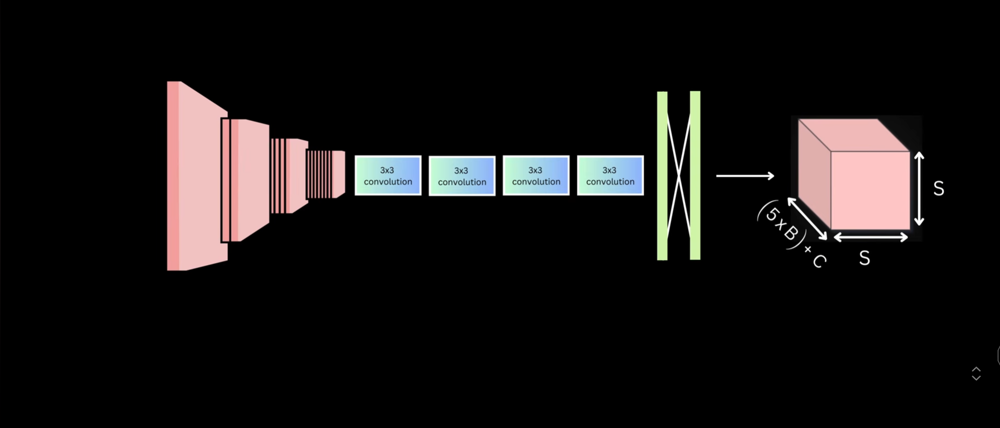

#### d: Sàng lọc thô bằng Ngưỡng (Thresholding) – Vòng Loại Trực Tiếp

Trong số 98 chiếc hộp vừa được phong danh xưng, thực tế có đến hơn 80 chiếc hộp là rác (rơi vào bầu trời, bãi cỏ, mặt đường). Nếu đưa toàn bộ 98 chiếc hộp này kèm theo ma trận điểm số khổng lồ vào màng lọc NMS (ở giai đoạn sau), thuật toán sẽ phải thực hiện hàng ngàn phép tính cắt nhau rất nặng nề và lãng phí. Giai đoạn 4 sinh ra để làm vòng "sơ khảo".

- **Bước 4.1: Áp dụng Lưới lọc (Threshold):** Các kỹ sư thường cài đặt một ngưỡng an toàn, ví dụ $Threshold = 0.2$ (hoặc $0.1$ tùy bài toán).
- **Bước 4.2: Chặt cụt tín hiệu yếu:** Hệ thống duyệt qua ma trận $98 \times 20$ điểm số chung cuộc. Tại bất kỳ ô điểm nào có giá trị $< 0.2$, nó trực tiếp ép con số đó về $0$.
  - Ví dụ: Chiếc hộp số 42 nằm ở giữa bầu trời. Điểm số cao nhất của nó là danh mục "Chim" nhưng chỉ đạt $0.05$ (do nó thấy một đám mây hơi giống cánh chim). Vì $0.05 < 0.2$, toàn bộ điểm của hộp này bị ép về $0$.
- **Bước 4.3: Hủy diệt các hộp rác:** Những chiếc hộp mà cả 20 danh mục đều bị ép về $0$ sẽ bị đánh dấu là "Hộp rỗng" và bị loại bỏ ngay lập tức khỏi luồng dữ liệu để giải phóng bộ nhớ (RAM/VRAM).
- **Hậu quả của Giai đoạn 4:** Chỉ bằng một phép so sánh lớn bé cực kỳ rẻ tiền về mặt thuật toán, cỗ máy đã quét sạch 80-90% lượng rác thải không gian. Khối lượng dữ liệu đổ vào Giai đoạn 5 (NMS) giờ đây rất nhẹ, chỉ còn lại khoảng chục chiếc hộp thực sự bao quanh các vật thể rõ ràng, giúp tốc độ khung hình (FPS) của YOLO được đẩy lên mức tối đa.

#### e: Triệt tiêu Cực đại Địa phương (Non-Maximum Suppression - NMS)

- **Mục đích:** Giải quyết triệt để bài toán trùng lặp. Ngay cả khi đã qua vòng lọc thô, một chiếc xe hơi trên ảnh vẫn có thể bị 3-4 chiếc hộp tiềm năng cùng khoanh trúng. NMS là màng lọc khốc liệt nhất để chọn ra "Người chiến thắng duy nhất".
- **Thực thi:** Quá trình này được thực hiện lặp lại trên từng danh mục vật thể riêng biệt (Ví dụ: dọn dẹp nhóm Xe hơi riêng, nhóm Người riêng).
  - **Bước 1 - Xếp hạng:** Xếp hạng các hộp có chứa điểm Xe hơi từ cao xuống thấp (Ví dụ: Hộp A - $0.9$, Hộp B - $0.8$, Hộp C - $0.7$).
  - **Bước 2 - Lấy Vua làm chuẩn:** Chốt Hộp A (điểm cao nhất) là hộp chính thức được giữ lại.
  - **Bước 3 - Triệt hạ phe cánh:** Đem tọa độ của Hộp A đo IOU với Hộp B và Hộp C. Nếu Hộp B có IOU với Hộp A quá cao (chẳng hạn $> 0.5$, nghĩa là chúng đè lên nhau quá nhiều, cùng trỏ về một chiếc xe), Hộp B lập tức bị xóa sổ.
  - **Bước 4 - Lặp lại:** Tiếp tục lấy hộp có điểm cao nhất trong danh sách sống sót còn lại làm chuẩn và lặp lại quá trình quét IOU cho đến khi không còn hộp nào đè lên nhau.

#### 7: Hậu xử lý và Dịch ngược Tọa độ (Post-processing & Rendering)

- **Mục đích:** Biến các con số toán học khô khan thành khung hình trực quan hiển thị trên màn hình giao diện.
- **Thực thi:**
  - Những chiếc hộp tinh anh cuối cùng sống sót qua màng lọc NMS hiện đang mang tọa độ ở hệ phân số từ $0$ đến $1$ (do thiết kế của mạng).
  - Hệ thống thực hiện phép tính nhân ngược lại: Lấy tọa độ $(x, y, w, h)$ nhân với kích thước chiều rộng và chiều cao nguyên bản của bức ảnh thực tế (Ví dụ: nhân với $1920 \times 1080$).
  - Phần mềm đồ họa lấy các thông số vật lý vừa dịch ngược để vẽ các khung hình chữ nhật (Bounding Boxes) đè lên video gốc, kèm theo một nhãn text hiển thị danh mục và tỷ lệ % (Ví dụ: "Car: 90%").

**Tổng kết:** Toàn bộ chuỗi 6 giai đoạn trên, từ lúc bức ảnh chạm vào ống kính đến khi hiển thị chiếc hộp hoàn chỉnh, chỉ mất vỏn vẹn khoảng 22 mili-giây (với YOLOv1 trên GPU Titan X năm 2015), đạt tốc độ 45 khung hình/giây. Đó là minh chứng cho sự tối ưu tuyệt đối của triết lý "One-Stage" mà YOLO mang lại!

**KẾT LUẬN CHUNG**

Bằng cách gộp chung việc định vị hình học và phân loại hình ảnh vào một cơ chế vận hành khép kín (End-to-End), YOLOv1 không chỉ loại bỏ đi sự cồng kềnh của các thế hệ R-CNN trước đó mà còn xác lập một quy chuẩn hoàn toàn mới cho ngành Trí tuệ Nhân tạo. Dù trải qua nhiều phiên bản nâng cấp sau này, triết lý "nhìn một lần" và thiết kế hàm Loss nguyên bản của YOLOv1 vẫn luôn là một trong những kiệt tác toán học kinh điển nhất của Thị giác Máy tính hiện đại.


